In [ ]:
# ============================================================
# TRAVEL DEMAND, PRICING & OCCUPANCY ANALYSIS
# PHASE 1: DATA UNDERSTANDING
# ============================================================

# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

# Menampilkan lebih banyak kolom saat melihat dataframe
pd.set_option("display.max_columns", None)

# Menampilkan angka desimal dengan 2 angka di belakang koma
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# ============================================================
# 2. LOAD DATASET
# ============================================================

# Membaca file Excel
df = pd.read_excel("Data_Travel.xlsx")

print("Dataset berhasil dibaca.")
print()


# ============================================================
# 3. MELIHAT 5 DATA PERTAMA
# ============================================================

print("=== 5 DATA PERTAMA ===")
display(df.head())


# ============================================================
# 4. UKURAN DATASET
# ============================================================

print("=== UKURAN DATASET ===")

jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]

print(f"Jumlah baris  : {jumlah_baris:,}")
print(f"Jumlah kolom  : {jumlah_kolom}")

print()


# ============================================================
# 5. DAFTAR NAMA KOLOM
# ============================================================

print("=== DAFTAR KOLOM ===")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print()


# ============================================================
# 6. INFORMASI DATASET
# ============================================================

print("=== INFORMASI DATASET ===")

df.info()

print()


# ============================================================
# 7. RINGKASAN DATASET
# ============================================================

print("=== RINGKASAN DATASET ===")

summary = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.astype(str),
    "Jumlah Data": df.notna().sum(),
    "Missing Value": df.isna().sum(),
    "Persentase Missing (%)": (
        df.isna().sum() / len(df) * 100
    ).round(2),
    "Jumlah Unik": df.nunique()
})

display(summary)


# ============================================================
# 8. CEK MISSING VALUE
# ============================================================

print("=== MISSING VALUE ===")

missing = pd.DataFrame({
    "Jumlah Missing": df.isna().sum(),
    "Persentase (%)": (
        df.isna().sum() / len(df) * 100
    ).round(2)
})

# Hanya menampilkan kolom yang memiliki missing value
missing = missing[missing["Jumlah Missing"] > 0]

if len(missing) == 0:
    print("Tidak terdapat missing value.")
else:
    display(missing.sort_values(
        by="Jumlah Missing",
        ascending=False
    ))


# ============================================================
# 9. CEK DUPLICATE
# ============================================================

print("=== DUPLICATE ===")

jumlah_duplicate = df.duplicated().sum()

print(f"Jumlah baris duplicate: {jumlah_duplicate:,}")

persentase_duplicate = (
    jumlah_duplicate / len(df) * 100
)

print(f"Persentase duplicate  : {persentase_duplicate:.2f}%")

print()


# ============================================================
# 10. CEK ID TRAVEL
# ============================================================

print("=== ID TRAVEL ===")

if "id_travel" in df.columns:

    jumlah_id = df["id_travel"].nunique()

    print(f"Jumlah ID unik        : {jumlah_id:,}")
    print(f"Jumlah total data     : {len(df):,}")
    print(
        f"Apakah ID semuanya unik? "
        f"{jumlah_id == len(df)}"
    )

else:
    print("Kolom id_travel tidak ditemukan.")

print()


# ============================================================
# 11. JUMLAH OPERATOR TRAVEL
# ============================================================

print("=== OPERATOR TRAVEL ===")

if "nama" in df.columns:

    jumlah_operator = df["nama"].nunique()

    print(f"Jumlah operator: {jumlah_operator}")

    print("\n10 operator dengan jumlah perjalanan terbanyak:")

    operator_count = (
        df["nama"]
        .value_counts()
        .head(10)
    )

    display(operator_count)

else:
    print("Kolom nama tidak ditemukan.")

print()


# ============================================================
# 12. ANALISIS RUTE
# ============================================================

print("=== ANALISIS RUTE ===")

if "asal" in df.columns and "tujuan" in df.columns:

    # Membuat kolom rute
    df["rute"] = (
        df["asal"].astype(str)
        + " → "
        + df["tujuan"].astype(str)
    )

    jumlah_rute = df["rute"].nunique()

    print(f"Jumlah rute unik: {jumlah_rute}")

    print("\n10 rute dengan jumlah perjalanan terbanyak:")

    route_count = (
        df["rute"]
        .value_counts()
        .head(10)
    )

    display(route_count)

else:
    print("Kolom asal atau tujuan tidak ditemukan.")

print()


# ============================================================
# 13. ANALISIS KOTA ASAL
# ============================================================

print("=== KOTA ASAL ===")

if "asal" in df.columns:

    print(f"Jumlah kota asal: {df['asal'].nunique()}")

    display(
        df["asal"]
        .value_counts()
        .head(10)
    )

print()


# ============================================================
# 14. ANALISIS KOTA TUJUAN
# ============================================================

print("=== KOTA TUJUAN ===")

if "tujuan" in df.columns:

    print(f"Jumlah kota tujuan: {df['tujuan'].nunique()}")

    display(
        df["tujuan"]
        .value_counts()
        .head(10)
    )

print()


# ============================================================
# 15. ANALISIS TANGGAL
# ============================================================

print("=== ANALISIS TANGGAL ===")

if "tanggal" in df.columns:

    # Mengubah tanggal menjadi format datetime
    # errors='coerce' membuat data tanggal yang tidak valid
    # menjadi NaT sehingga bisa kita identifikasi
    df["tanggal"] = pd.to_datetime(
        df["tanggal"],
        errors="coerce"
    )

    print(f"Tanggal paling awal : {df['tanggal'].min()}")
    print(f"Tanggal paling akhir: {df['tanggal'].max()}")
    print(f"Jumlah tanggal unik : {df['tanggal'].nunique():,}")

    print(
        f"Jumlah tanggal tidak valid: "
        f"{df['tanggal'].isna().sum():,}"
    )

print()


# ============================================================
# 16. ANALISIS HARGA
# ============================================================

print("=== ANALISIS HARGA TIKET ===")

if "harga" in df.columns:

    print(f"Harga minimum : Rp {df['harga'].min():,.0f}")
    print(f"Harga maksimum : Rp {df['harga'].max():,.0f}")
    print(f"Harga rata-rata: Rp {df['harga'].mean():,.0f}")
    print(f"Harga median   : Rp {df['harga'].median():,.0f}")

    print("\nStatistik deskriptif harga:")

    display(
        df["harga"].describe()
    )

else:
    print("Kolom harga tidak ditemukan.")

print()


# ============================================================
# 17. ANALISIS KELAS
# ============================================================

print("=== KELAS PERJALANAN ===")

if "kelas" in df.columns:

    print(f"Jumlah kelas unik: {df['kelas'].nunique()}")

    display(
        df["kelas"]
        .value_counts()
    )

else:
    print("Kolom kelas tidak ditemukan.")

print()


# ============================================================
# 18. ANALISIS TIPE
# ============================================================

print("=== TIPE LAYANAN ===")

if "tipe" in df.columns:

    print(f"Jumlah tipe unik: {df['tipe'].nunique()}")

    display(
        df["tipe"]
        .value_counts()
    )

else:
    print("Kolom tipe tidak ditemukan.")

print()


# ============================================================
# 19. ANALISIS TIPE KURSI
# ============================================================

print("=== TIPE KURSI ===")

if "tipe_kursi" in df.columns:

    print(f"Jumlah tipe kursi unik: {df['tipe_kursi'].nunique()}")

    display(
        df["tipe_kursi"]
        .value_counts()
    )

else:
    print("Kolom tipe_kursi tidak ditemukan.")

print()


# ============================================================
# 20. ANALISIS JAM KEBERANGKATAN
# ============================================================

print("=== JAM KEBERANGKATAN ===")

if "jam_berangkat" in df.columns:

    print("5 data jam keberangkatan pertama:")

    display(
        df["jam_berangkat"]
        .head()
    )

    print(
        "\nJumlah nilai unik jam keberangkatan:",
        df["jam_berangkat"].nunique()
    )

else:
    print("Kolom jam_berangkat tidak ditemukan.")

print()


# ============================================================
# 21. ANALISIS JAM KEDATANGAN
# ============================================================

print("=== JAM KEDATANGAN ===")

if "jam_datang" in df.columns:

    print("5 data jam kedatangan pertama:")

    display(
        df["jam_datang"]
        .head()
    )

    print(
        "\nJumlah nilai unik jam kedatangan:",
        df["jam_datang"].nunique()
    )

else:
    print("Kolom jam_datang tidak ditemukan.")

print()


# ============================================================
# 22. ANALISIS KURSI TERISI
# ============================================================

print("=== KURSI TERISI ===")

# Mengantisipasi typo nama kolom
kolom_terisi = None

if "Tempat_duduk_terisi" in df.columns:
    kolom_terisi = "Tempat_duduk_terisi"

elif "Termpat_duduk_terisi" in df.columns:
    kolom_terisi = "Termpat_duduk_terisi"

if kolom_terisi:

    print(f"Kolom yang digunakan: {kolom_terisi}")

    display(
        df[kolom_terisi].describe()
    )

else:
    print(
        "Kolom tempat duduk terisi tidak ditemukan."
    )

print()


# ============================================================
# 23. ANALISIS KURSI TERSISA
# ============================================================

print("=== KURSI TERSISA ===")

if "sisa_tempat_duduk" in df.columns:

    display(
        df["sisa_tempat_duduk"].describe()
    )

else:
    print(
        "Kolom sisa_tempat_duduk tidak ditemukan."
    )

print()


# ============================================================
# 24. CEK NILAI NEGATIF
# ============================================================

print("=== CEK NILAI NEGATIF ===")

kolom_numerik = df.select_dtypes(
    include=np.number
).columns

negative_summary = {}

for col in kolom_numerik:

    jumlah_negatif = (
        df[col] < 0
    ).sum()

    if jumlah_negatif > 0:
        negative_summary[col] = jumlah_negatif

if len(negative_summary) == 0:

    print("Tidak ditemukan nilai negatif pada kolom numerik.")

else:

    negative_df = pd.DataFrame(
        list(negative_summary.items()),
        columns=["Kolom", "Jumlah Nilai Negatif"]
    )

    display(negative_df)

print()


# ============================================================
# 25. MEMBUAT TOTAL KAPASITAS
# ============================================================

print("=== ANALISIS KAPASITAS ===")

if (
    kolom_terisi is not None
    and "sisa_tempat_duduk" in df.columns
):

    df["total_kapasitas"] = (
        df[kolom_terisi]
        + df["sisa_tempat_duduk"]
    )

    print("Total kapasitas berhasil dibuat.")

    print("\nStatistik total kapasitas:")

    display(
        df["total_kapasitas"].describe()
    )

else:

    print(
        "Total kapasitas belum dapat dihitung "
        "karena kolom kursi tidak lengkap."
    )

print()


# ============================================================
# 26. PREVIEW DATASET SETELAH DATA UNDERSTANDING
# ============================================================

print("=== PREVIEW DATASET ===")

display(
    df.head()
)

print()


# ============================================================
# 27. RINGKASAN DATA UNDERSTANDING
# ============================================================

print("=" * 60)
print("RINGKASAN DATA UNDERSTANDING")
print("=" * 60)

print(f"Jumlah baris             : {len(df):,}")
print(f"Jumlah kolom             : {df.shape[1]}")

if "nama" in df.columns:
    print(f"Jumlah operator          : {df['nama'].nunique()}")

if "rute" in df.columns:
    print(f"Jumlah rute              : {df['rute'].nunique()}")

if "tanggal" in df.columns:
    print(f"Jumlah tanggal unik      : {df['tanggal'].nunique():,}")
    print(f"Periode                  : {df['tanggal'].min()} sampai {df['tanggal'].max()}")

if "harga" in df.columns:
    print(f"Harga minimum            : Rp {df['harga'].min():,.0f}")
    print(f"Harga maksimum           : Rp {df['harga'].max():,.0f}")
    print(f"Harga rata-rata          : Rp {df['harga'].mean():,.0f}")
    print(f"Harga median             : Rp {df['harga'].median():,.0f}")

print(f"Jumlah duplicate         : {df.duplicated().sum():,}")

print(f"Total missing value      : {df.isna().sum().sum():,}")

print("=" * 60)
print("DATA UNDERSTANDING SELESAI")
print("=" * 60)

Dataset berhasil dibaca.

=== 5 DATA PERTAMA ===


,id_travel,nama,asal,tujuan,kelas,tipe,tipe_kursi,harga,tanggal,jam_berangkat,jam_datang,sisa_tempat_duduk,Termpat_duduk_terisi,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,redbus-1076686449620211778-27410-257186-27355-...,Mr trans - Shuttle Executive,Bandung,Jakarta,Executive,SHUTTLE,1-1,103899,2024-08-02,20:45,23:30,14,0,NaN,NaN,NaN
1,redbus-1076686449620211779-27410-257185-27355-...,Mr trans - Shuttle Executive,Bandung,Jakarta,Executive,SHUTTLE,1-1,103899,2024-08-02,20:30,23:30,14,0,NaN,NaN,Keterangan:
2,redbus-1076686449620544853-27410-5456497-27355...,Aragon shuttle - Shuttle Toyota HiAce,Bandung,Jakarta,Shuttle Toyota HiAce,SHUTTLE,1-1,124001,2024-08-02,18:30,22:30,9,5,NaN,NaN,1. Shuttle 1-1 = 14
3,redbus-1076686449620544854-27410-5456497-27355...,Aragon shuttle - Shuttle Toyota HiAce,Bandung,Jakarta,Shuttle Toyota HiAce,SHUTTLE,1-1,124001,2024-08-02,16:30,20:30,9,5,NaN,NaN,2. Shuttle 1-1-1 = 15
4,redbus-1076686449620544863-27410-5456497-27355...,Aragon shuttle - Shuttle Toyota HiAce,Bandung,Jakarta,Shuttle Toyota HiAce,SHUTTLE,1-1,129001,2024-08-02,20:15,00:15,8,6,NaN,NaN,3. Shuttle 1-2 = 18


=== UKURAN DATASET ===
Jumlah baris  : 548,087
Jumlah kolom  : 16

=== DAFTAR KOLOM ===
1. id_travel
2. nama
3. asal
4. tujuan
5. kelas
6. tipe
7. tipe_kursi
8. harga
9. tanggal
10. jam_berangkat
11. jam_datang
12. sisa_tempat_duduk
13. Termpat_duduk_terisi
14. Unnamed: 13
15. Unnamed: 14
16. Unnamed: 15

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548087 entries, 0 to 548086
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_travel             548087 non-null  object 
 1   nama                  548087 non-null  object 
 2   asal                  548087 non-null  object 
 3   tujuan                548087 non-null  object 
 4   kelas                 548087 non-null  object 
 5   tipe                  548087 non-null  object 
 6   tipe_kursi            548087 non-null  object 
 7   harga                 548087 non-null  int64  
 8   tanggal               548087 no

,Kolom,Tipe Data,Jumlah Data,Missing Value,Persentase Missing (%),Jumlah Unik
id_travel,id_travel,object,548087,0,0.00,548087
nama,nama,object,548087,0,0.00,55
asal,asal,object,548087,0,0.00,1
tujuan,tujuan,object,548087,0,0.00,5
kelas,kelas,object,548087,0,0.00,22
tipe,tipe,object,548087,0,0.00,2
tipe_kursi,tipe_kursi,object,548087,0,0.00,6
harga,harga,int64,548087,0,0.00,1231
tanggal,tanggal,object,548087,0,0.00,169
jam_berangkat,jam_berangkat,object,548087,0,0.00,303


=== MISSING VALUE ===


...


=== ANALISIS KAPASITAS ===
Total kapasitas berhasil dibuat.

Statistik total kapasitas:


,total_kapasitas
count,"548,087.00"
mean,17.50
std,6.99
min,14.00
25%,14.00
50%,18.00
75%,18.00
max,60.00



=== PREVIEW DATASET ===


,id_travel,nama,asal,tujuan,kelas,tipe,tipe_kursi,harga,tanggal,jam_berangkat,jam_datang,sisa_tempat_duduk,Termpat_duduk_terisi,Unnamed: 13,Unnamed: 14,Unnamed: 15,rute,total_kapasitas
0,redbus-1076686449620211778-27410-257186-27355-...,Mr trans - Shuttle Executive,Bandung,Jakarta,Executive,SHUTTLE,1-1,103899,2024-08-02,20:45,23:30,14,0,NaN,NaN,NaN,Bandung → Jakarta,14
1,redbus-1076686449620211779-27410-257185-27355-...,Mr trans - Shuttle Executive,Bandung,Jakarta,Executive,SHUTTLE,1-1,103899,2024-08-02,20:30,23:30,14,0,NaN,NaN,Keterangan:,Bandung → Jakarta,14
2,redbus-1076686449620544853-27410-5456497-27355...,Aragon shuttle - Shuttle Toyota HiAce,Bandung,Jakarta,Shuttle Toyota HiAce,SHUTTLE,1-1,124001,2024-08-02,18:30,22:30,9,5,NaN,NaN,1. Shuttle 1-1 = 14,Bandung → Jakarta,14
3,redbus-1076686449620544854-27410-5456497-27355...,Aragon shuttle - Shuttle Toyota HiAce,Bandung,Jakarta,Shuttle Toyota HiAce,SHUTTLE,1-1,124001,2024-08-02,16:30,20:30,9,5,NaN,NaN,2. Shuttle 1-1-1 = 15,Bandung → Jakarta,14
4,redbus-1076686449620544863-27410-5456497-27355...,Aragon shuttle - Shuttle Toyota HiAce,Bandung,Jakarta,Shuttle Toyota HiAce,SHUTTLE,1-1,129001,2024-08-02,20:15,00:15,8,6,NaN,NaN,3. Shuttle 1-2 = 18,Bandung → Jakarta,14



RINGKASAN DATA UNDERSTANDING
Jumlah baris             : 548,087
Jumlah kolom             : 18
Jumlah operator          : 55
Jumlah rute              : 5
Jumlah tanggal unik      : 169
Periode                  : 2024-08-02 00:00:00 sampai 2025-02-12 00:00:00
Harga minimum            : Rp 15,000
Harga maksimum           : Rp 1,049,500
Harga rata-rata          : Rp 131,586
Harga median             : Rp 115,051
Jumlah duplicate         : 0
Total missing value      : 1,644,252
DATA UNDERSTANDING SELESAI


In [ ]:
# ============================================================
# TRAVEL DEMAND, PRICING & OCCUPANCY ANALYSIS
# PHASE 2 : DATA CLEANING
# ============================================================

import pandas as pd
import numpy as np

# Pengaturan tampilan
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# ============================================================
# 1. LOAD DATA
# ============================================================

print("=" * 70)
print("1. LOAD DATASET")
print("=" * 70)

df = pd.read_excel("Data_Travel.xlsx")

print(f"Jumlah baris awal  : {len(df):,}")
print(f"Jumlah kolom awal  : {df.shape[1]}")
print()


# ============================================================
# 2. MEMBUAT SALINAN DATA
# ============================================================

print("=" * 70)
print("2. MEMBUAT SALINAN DATA")
print("=" * 70)

df_clean = df.copy()

print("Salinan dataset berhasil dibuat.")
print()


# ============================================================
# 3. HAPUS KOLOM YANG TIDAK DIPERLUKAN
# ============================================================

print("=" * 70)
print("3. MENGHAPUS KOLOM TIDAK DIPERLUKAN")
print("=" * 70)

kolom_hapus = [
    "Unnamed: 13",
    "Unnamed: 14",
    "Unnamed: 15"
]

# Cek kolom mana yang benar-benar ada
kolom_tersedia = [
    col for col in kolom_hapus
    if col in df_clean.columns
]

df_clean = df_clean.drop(
    columns=kolom_tersedia
)

print("Kolom yang dihapus:")

for col in kolom_tersedia:
    print(f"- {col}")

print()
print(f"Jumlah kolom setelah cleaning awal: {df_clean.shape[1]}")
print()


# ============================================================
# 4. MEMPERBAIKI NAMA KOLOM
# ============================================================

print("=" * 70)
print("4. MEMPERBAIKI NAMA KOLOM")
print("=" * 70)

rename_columns = {
    "Termpat_duduk_terisi": "tempat_duduk_terisi"
}

df_clean = df_clean.rename(
    columns=rename_columns
)

print("Perubahan nama kolom:")

for old, new in rename_columns.items():

    if new in df_clean.columns:
        print(f"- {old} → {new}")

print()


# ============================================================
# 5. MELIHAT STRUKTUR DATA SETELAH CLEANING AWAL
# ============================================================

print("=" * 70)
print("5. STRUKTUR DATA")
print("=" * 70)

print("Daftar kolom:")

for i, col in enumerate(df_clean.columns, start=1):
    print(f"{i}. {col}")

print()


# ============================================================
# 6. KONVERSI TIPE DATA
# ============================================================

print("=" * 70)
print("6. KONVERSI TIPE DATA")
print("=" * 70)

# Tanggal
if "tanggal" in df_clean.columns:

    df_clean["tanggal"] = pd.to_datetime(
        df_clean["tanggal"],
        errors="coerce"
    )

# Harga
if "harga" in df_clean.columns:

    df_clean["harga"] = pd.to_numeric(
        df_clean["harga"],
        errors="coerce"
    )

# Kursi tersisa
if "sisa_tempat_duduk" in df_clean.columns:

    df_clean["sisa_tempat_duduk"] = pd.to_numeric(
        df_clean["sisa_tempat_duduk"],
        errors="coerce"
    )

# Kursi terisi
if "tempat_duduk_terisi" in df_clean.columns:

    df_clean["tempat_duduk_terisi"] = pd.to_numeric(
        df_clean["tempat_duduk_terisi"],
        errors="coerce"
    )

print("Tipe data setelah konversi:")

print(
    df_clean.dtypes
)

print()


# ============================================================
# 7. CEK MISSING VALUE
# ============================================================

print("=" * 70)
print("7. CEK MISSING VALUE")
print("=" * 70)

missing_clean = pd.DataFrame({
    "Kolom": df_clean.columns,
    "Missing Value": df_clean.isna().sum(),
    "Persentase (%)": (
        df_clean.isna().sum()
        / len(df_clean)
        * 100
    ).round(2)
})

display(missing_clean)

total_missing = df_clean.isna().sum().sum()

print()
print(f"Total missing value: {total_missing:,}")
print()


# ============================================================
# 8. CEK DUPLICATE
# ============================================================

print("=" * 70)
print("8. CEK DUPLICATE")
print("=" * 70)

jumlah_duplicate = df_clean.duplicated().sum()

print(
    f"Jumlah duplicate : {jumlah_duplicate:,}"
)

print(
    f"Persentase       : "
    f"{jumlah_duplicate / len(df_clean) * 100:.2f}%"
)

print()


# ============================================================
# 9. CEK ID TRAVEL
# ============================================================

print("=" * 70)
print("9. CEK ID TRAVEL")
print("=" * 70)

if "id_travel" in df_clean.columns:

    jumlah_id_unik = df_clean["id_travel"].nunique()

    print(
        f"Jumlah ID unik : {jumlah_id_unik:,}"
    )

    print(
        f"Jumlah data    : {len(df_clean):,}"
    )

    print(
        f"Semua ID unik? : "
        f"{jumlah_id_unik == len(df_clean)}"
    )

print()


# ============================================================
# 10. MEMBUAT KOLOM RUTE
# ============================================================

print("=" * 70)
print("10. MEMBUAT KOLOM RUTE")
print("=" * 70)

if (
    "asal" in df_clean.columns
    and "tujuan" in df_clean.columns
):

    df_clean["rute"] = (
        df_clean["asal"].astype(str)
        + " → "
        + df_clean["tujuan"].astype(str)
    )

    print(
        f"Jumlah rute unik: "
        f"{df_clean['rute'].nunique()}"
    )

    print("\n10 rute terbanyak:")

    display(
        df_clean["rute"]
        .value_counts()
        .head(10)
    )

print()


# ============================================================
# 11. INVESTIGASI KURSI TERISI NEGATIF
# ============================================================

print("=" * 70)
print("11. INVESTIGASI KURSI TERISI NEGATIF")
print("=" * 70)

if "tempat_duduk_terisi" in df_clean.columns:

    data_negatif = df_clean[
        df_clean["tempat_duduk_terisi"] < 0
    ].copy()

    jumlah_negatif = len(data_negatif)

    print(
        f"Jumlah data kursi terisi negatif: "
        f"{jumlah_negatif:,}"
    )

    if jumlah_negatif > 0:

        print("\nDistribusi nilai negatif:")

        display(
            data_negatif[
                "tempat_duduk_terisi"
            ]
            .value_counts()
            .sort_index()
        )

        print("\nContoh 20 data negatif:")

        kolom_tampil = [
            "id_travel",
            "nama",
            "asal",
            "tujuan",
            "kelas",
            "tipe",
            "tipe_kursi",
            "harga",
            "tanggal",
            "jam_berangkat",
            "jam_datang",
            "sisa_tempat_duduk",
            "tempat_duduk_terisi"
        ]

        kolom_tampil = [
            col for col in kolom_tampil
            if col in data_negatif.columns
        ]

        display(
            data_negatif[
                kolom_tampil
            ].head(20)
        )

print()


# ============================================================
# 12. ANALISIS POLA DATA NEGATIF
# ============================================================

print("=" * 70)
print("12. POLA DATA KURSI NEGATIF")
print("=" * 70)

if "tempat_duduk_terisi" in df_clean.columns:

    if len(data_negatif) > 0:

        print("Kursi negatif berdasarkan operator:")

        display(
            data_negatif["nama"]
            .value_counts()
            .head(20)
        )

        print("\nKursi negatif berdasarkan kelas:")

        display(
            data_negatif["kelas"]
            .value_counts()
            .head(20)
        )

        print("\nKursi negatif berdasarkan tipe:")

        display(
            data_negatif["tipe"]
            .value_counts()
        )

print()


# ============================================================
# 13. MEMERIKSA HUBUNGAN KURSI NEGATIF
#     DENGAN KURSI TERSISA
# ============================================================

print("=" * 70)
print("13. HUBUNGAN KURSI TERISI & KURSI TERSISA")
print("=" * 70)

if len(data_negatif) > 0:

    pola_kursi = (
        data_negatif[
            [
                "tempat_duduk_terisi",
                "sisa_tempat_duduk"
            ]
        ]
        .value_counts()
        .reset_index(
            name="jumlah"
        )
        .sort_values(
            "jumlah",
            ascending=False
        )
        .head(20)
    )

    display(pola_kursi)

print()


# ============================================================
# 14. MEMERIKSA HARGA EKSTREM
# ============================================================

print("=" * 70)
print("14. INVESTIGASI HARGA EKSTREM")
print("=" * 70)

if "harga" in df_clean.columns:

    harga_ekstrem = df_clean[
        df_clean["harga"] >= 500000
    ].copy()

    print(
        "Jumlah perjalanan dengan "
        "harga >= Rp500.000:",
        f"{len(harga_ekstrem):,}"
    )

    if len(harga_ekstrem) > 0:

        kolom_harga = [
            "nama",
            "asal",
            "tujuan",
            "kelas",
            "tipe",
            "tipe_kursi",
            "harga",
            "tanggal",
            "jam_berangkat",
            "jam_datang"
        ]

        kolom_harga = [
            col for col in kolom_harga
            if col in harga_ekstrem.columns
        ]

        display(
            harga_ekstrem[
                kolom_harga
            ]
            .sort_values(
                "harga",
                ascending=False
            )
            .head(20)
        )

print()


# ============================================================
# 15. MEMERIKSA HARGA SANGAT RENDAH
# ============================================================

print("=" * 70)
print("15. INVESTIGASI HARGA RENDAH")
print("=" * 70)

if "harga" in df_clean.columns:

    harga_rendah = df_clean[
        df_clean["harga"] <= 50000
    ].copy()

    print(
        "Jumlah perjalanan dengan "
        "harga <= Rp50.000:",
        f"{len(harga_rendah):,}"
    )

    if len(harga_rendah) > 0:

        kolom_harga_rendah = [
            "nama",
            "asal",
            "tujuan",
            "kelas",
            "tipe",
            "tipe_kursi",
            "harga",
            "tanggal"
        ]

        kolom_harga_rendah = [
            col for col in kolom_harga_rendah
            if col in harga_rendah.columns
        ]

        display(
            harga_rendah[
                kolom_harga_rendah
            ]
            .sort_values(
                "harga"
            )
            .head(20)
        )

print()


# ============================================================
# 16. MEMBUAT TOTAL KAPASITAS SEMENTARA
# ============================================================

print("=" * 70)
print("16. TOTAL KAPASITAS")
print("=" * 70)

if (
    "tempat_duduk_terisi" in df_clean.columns
    and "sisa_tempat_duduk" in df_clean.columns
):

    df_clean["total_kapasitas"] = (
        df_clean["tempat_duduk_terisi"]
        + df_clean["sisa_tempat_duduk"]
    )

    display(
        df_clean[
            "total_kapasitas"
        ].describe()
    )

print()


# ============================================================
# 17. CEK KAPASITAS TIDAK VALID
# ============================================================

print("=" * 70)
print("17. CEK KAPASITAS TIDAK VALID")
print("=" * 70)

if "total_kapasitas" in df_clean.columns:

    kapasitas_nol = df_clean[
        df_clean["total_kapasitas"] <= 0
    ]

    kapasitas_besar = df_clean[
        df_clean["total_kapasitas"] > 60
    ]

    print(
        "Kapasitas <= 0 :",
        f"{len(kapasitas_nol):,}"
    )

    print(
        "Kapasitas > 60  :",
        f"{len(kapasitas_besar):,}"
    )

    if len(kapasitas_besar) > 0:

        print("\nContoh kapasitas > 60:")

        display(
            kapasitas_besar[
                [
                    "nama",
                    "kelas",
                    "tipe",
                    "tipe_kursi",
                    "sisa_tempat_duduk",
                    "tempat_duduk_terisi",
                    "total_kapasitas"
                ]
            ].head(20)
        )

print()


# ============================================================
# 18. KAPASITAS BERDASARKAN TIPE KURSI
# ============================================================

print("=" * 70)
print("18. KAPASITAS BERDASARKAN TIPE KURSI")
print("=" * 70)

if (
    "tipe_kursi" in df_clean.columns
    and "total_kapasitas" in df_clean.columns
):

    kapasitas_summary = (
        df_clean
        .groupby(
            "tipe_kursi",
            dropna=False
        )
        .agg(
            jumlah_data=(
                "id_travel",
                "count"
            ),
            min_kapasitas=(
                "total_kapasitas",
                "min"
            ),
            median_kapasitas=(
                "total_kapasitas",
                "median"
            ),
            rata_kapasitas=(
                "total_kapasitas",
                "mean"
            ),
            max_kapasitas=(
                "total_kapasitas",
                "max"
            )
        )
        .reset_index()
    )

    display(kapasitas_summary)

print()


# ============================================================
# 19. CEK NILAI NEGATIF PADA SEMUA KOLOM NUMERIK
# ============================================================

print("=" * 70)
print("19. CEK NILAI NEGATIF")
print("=" * 70)

kolom_numerik = df_clean.select_dtypes(
    include=np.number
).columns

negative_summary = []

for col in kolom_numerik:

    jumlah = (
        df_clean[col] < 0
    ).sum()

    negative_summary.append({
        "Kolom": col,
        "Jumlah Nilai Negatif": jumlah
    })

negative_df = pd.DataFrame(
    negative_summary
)

display(negative_df)

print()


# ============================================================
# 20. CEK DATA TANGGAL TIDAK VALID
# ============================================================

print("=" * 70)
print("20. CEK TANGGAL")
print("=" * 70)

if "tanggal" in df_clean.columns:

    tanggal_invalid = df_clean[
        df_clean["tanggal"].isna()
    ]

    print(
        "Jumlah tanggal tidak valid:",
        f"{len(tanggal_invalid):,}"
    )

    print(
        "Tanggal paling awal:",
        df_clean["tanggal"].min()
    )

    print(
        "Tanggal paling akhir:",
        df_clean["tanggal"].max()
    )

print()


# ============================================================
# 21. CEK DATA HARGA TIDAK VALID
# ============================================================

print("=" * 70)
print("21. CEK HARGA TIDAK VALID")
print("=" * 70)

if "harga" in df_clean.columns:

    harga_invalid = df_clean[
        df_clean["harga"] <= 0
    ]

    print(
        "Jumlah harga <= 0:",
        f"{len(harga_invalid):,}"
    )

print()


# ============================================================
# 22. RINGKASAN DATA CLEANING
# ============================================================

print("=" * 70)
print("22. RINGKASAN DATA CLEANING")
print("=" * 70)

print(
    f"Jumlah baris              : "
    f"{len(df_clean):,}"
)

print(
    f"Jumlah kolom              : "
    f"{df_clean.shape[1]}"
)

print(
    f"Missing value             : "
    f"{df_clean.isna().sum().sum():,}"
)

print(
    f"Duplicate                 : "
    f"{df_clean.duplicated().sum():,}"
)

if "tempat_duduk_terisi" in df_clean.columns:

    print(
        f"Kursi terisi negatif     : "
        f"{(df_clean['tempat_duduk_terisi'] < 0).sum():,}"
    )

if "harga" in df_clean.columns:

    print(
        f"Harga <= 0               : "
        f"{(df_clean['harga'] <= 0).sum():,}"
    )

if "tanggal" in df_clean.columns:

    print(
        f"Tanggal tidak valid      : "
        f"{df_clean['tanggal'].isna().sum():,}"
    )

print()


# ============================================================
# 23. MENYIMPAN HASIL CLEANING TAHAP 1
# ============================================================

print("=" * 70)
print("23. MENYIMPAN DATA")
print("=" * 70)

output_file = "travel_data_cleaning_stage1.xlsx"

df_clean.to_excel(
    output_file,
    index=False
)

print(
    f"File berhasil disimpan sebagai:\n{output_file}"
)

print()


# ============================================================
# SELESAI
# ============================================================

print("=" * 70)
print("PHASE 2 — DATA CLEANING TAHAP 1 SELESAI")
print("=" * 70)

print("""
Data yang sudah dilakukan:
✓ Menghapus kolom tidak diperlukan
✓ Memperbaiki nama kolom
✓ Mengonversi tipe data
✓ Mengecek missing value
✓ Mengecek duplicate
✓ Mengecek ID unik
✓ Membuat kolom rute
✓ Menginvestigasi kursi negatif
✓ Menginvestigasi harga ekstrem
✓ Membuat total kapasitas sementara
✓ Mengecek kapasitas
✓ Menyimpan dataset hasil cleaning tahap 1

BELUM dilakukan:
✗ Menghapus data kursi negatif
✗ Menghapus outlier harga
✗ Menghitung occupancy rate final

Keputusan tersebut dilakukan setelah melihat hasil investigasi.
""")

1. LOAD DATASET
Jumlah baris awal  : 548,087
Jumlah kolom awal  : 16

2. MEMBUAT SALINAN DATA
Salinan dataset berhasil dibuat.

3. MENGHAPUS KOLOM TIDAK DIPERLUKAN
Kolom yang dihapus:
- Unnamed: 13
- Unnamed: 14
- Unnamed: 15

Jumlah kolom setelah cleaning awal: 13

4. MEMPERBAIKI NAMA KOLOM
Perubahan nama kolom:
- Termpat_duduk_terisi → tempat_duduk_terisi

5. STRUKTUR DATA
Daftar kolom:
1. id_travel
2. nama
3. asal
4. tujuan
5. kelas
6. tipe
7. tipe_kursi
8. harga
9. tanggal
10. jam_berangkat
11. jam_datang
12. sisa_tempat_duduk
13. tempat_duduk_terisi

6. KONVERSI TIPE DATA
Tipe data setelah konversi:
id_travel                      object
nama                           object
asal                           object
tujuan                         object
kelas                          object
tipe                           object
tipe_kursi                     object
harga                           int64
tanggal                datetime64[ns]
jam_berangkat                  object
jam_data

,Kolom,Missing Value,Persentase (%)
id_travel,id_travel,0,0.00
nama,nama,0,0.00
asal,asal,0,0.00
tujuan,tujuan,0,0.00
kelas,kelas,0,0.00
tipe,tipe,0,0.00
tipe_kursi,tipe_kursi,0,0.00
harga,harga,0,0.00
tanggal,tanggal,0,0.00
jam_berangkat,jam_berangkat,0,0.00



Total missing value: 0

8. CEK DUPLICATE
Jumlah duplicate : 0
Persentase       : 0.00%

9. CEK ID TRAVEL
Jumlah ID unik : 548,087
Jumlah data    : 548,087
Semua ID unik? : True

10. MEMBUAT KOLOM RUTE
Jumlah rute unik: 5

10 rute terbanyak:


,count
rute,
Bandung → Jakarta,501575
Bandung → Semarang,30422
Bandung → Surabaya,9709
Bandung → Yogyakarta,5175
Bandung → Serang,1206



11. INVESTIGASI KURSI TERISI NEGATIF
Jumlah data kursi terisi negatif: 1,007

Distribusi nilai negatif:


...


17. CEK KAPASITAS TIDAK VALID
Kapasitas <= 0 : 0
Kapasitas > 60  : 0

18. KAPASITAS BERDASARKAN TIPE KURSI


,tipe_kursi,jumlah_data,min_kapasitas,median_kapasitas,rata_kapasitas,max_kapasitas
0,1-1,279985,14,14.00,14.56,25
1,1-1-1,4954,15,15.00,15.00,15
2,1-2,239593,18,18.00,18.08,30
3,2-1,171,30,30.00,30.00,30
4,2-2,22508,20,50.00,46.86,50
5,3-2,876,60,60.00,60.00,60



19. CEK NILAI NEGATIF


,Kolom,Jumlah Nilai Negatif
0,harga,0
1,sisa_tempat_duduk,0
2,tempat_duduk_terisi,1007
3,total_kapasitas,0



20. CEK TANGGAL
Jumlah tanggal tidak valid: 0
Tanggal paling awal: 2024-08-02 00:00:00
Tanggal paling akhir: 2025-02-12 00:00:00

21. CEK HARGA TIDAK VALID
Jumlah harga <= 0: 0

22. RINGKASAN DATA CLEANING
Jumlah baris              : 548,087
Jumlah kolom              : 15
Missing value             : 0
Duplicate                 : 0
Kursi terisi negatif     : 1,007
Harga <= 0               : 0
Tanggal tidak valid      : 0

23. MENYIMPAN DATA
File berhasil disimpan sebagai:
travel_data_cleaning_stage1.xlsx

PHASE 2 — DATA CLEANING TAHAP 1 SELESAI

Data yang sudah dilakukan:
✓ Menghapus kolom tidak diperlukan
✓ Memperbaiki nama kolom
✓ Mengonversi tipe data
✓ Mengecek missing value
✓ Mengecek duplicate
✓ Mengecek ID unik
✓ Membuat kolom rute
✓ Menginvestigasi kursi negatif
✓ Menginvestigasi harga ekstrem
✓ Membuat total kapasitas sementara
✓ Mengecek kapasitas
✓ Menyimpan dataset hasil cleaning tahap 1

BELUM dilakukan:
✗ Menghapus data kursi negatif
✗ Menghapus outlier harga
✗ Menghitung

In [ ]:
# ============================================================
# UJI HIPOTESIS: NILAI NEGATIF = KURSI TERISI
# ============================================================

df_test = df_clean.copy()

# Ubah negatif menjadi nilai absolut
df_test["kursi_terisi_abs"] = df_test["tempat_duduk_terisi"].abs()

# Hitung kapasitas berdasarkan nilai absolut
df_test["kapasitas_abs"] = (
    df_test["kursi_terisi_abs"]
    + df_test["sisa_tempat_duduk"]
)

# Fokus pada data yang sebelumnya negatif
df_neg = df_test[
    df_test["tempat_duduk_terisi"] < 0
].copy()

print("=" * 70)
print("UJI HIPOTESIS NILAI NEGATIF")
print("=" * 70)

print("\nJumlah data negatif:", len(df_neg))

print("\nKapasitas setelah menggunakan ABS:")
print(
    df_neg["kapasitas_abs"].describe()
)

print("\nDistribusi kapasitas:")
print(
    df_neg["kapasitas_abs"]
    .value_counts()
    .sort_index()
)

print("\nKapasitas berdasarkan tipe kursi:")
print(
    df_neg.groupby("tipe_kursi")["kapasitas_abs"]
    .agg(["count", "min", "median", "mean", "max"])
)

print("\nKapasitas berdasarkan kelas:")
print(
    df_neg.groupby("kelas")["kapasitas_abs"]
    .agg(["count", "min", "median", "mean", "max"])
)

print("\nContoh data negatif setelah ABS:")

print(
    df_neg[
        [
            "nama",
            "kelas",
            "tipe",
            "tipe_kursi",
            "tempat_duduk_terisi",
            "sisa_tempat_duduk",
            "kursi_terisi_abs",
            "kapasitas_abs"
        ]
    ].head(20)
)

UJI HIPOTESIS NILAI NEGATIF

Jumlah data negatif: 1007

Kapasitas setelah menggunakan ABS:
count   1,007.00
mean       31.05
std        12.97
min        16.00
25%        22.00
50%        22.00
75%        43.00
max        62.00
Name: kapasitas_abs, dtype: float64

Distribusi kapasitas:
kapasitas_abs
16     11
18     67
20     40
22    457
24     24
26      2
28      4
32     46
34     37
36     23
38     18
40     22
42      4
44      3
46      2
48     11
50     45
52    181
56      4
60      2
62      4
Name: count, dtype: int64

Kapasitas berdasarkan tipe kursi:
            count  min  median  mean  max
tipe_kursi                               
1-1           615   16   22.00 22.29   56
1-2           392   24   50.00 44.80   62

Kapasitas berdasarkan kelas:
                      count  min  median  mean  max
kelas                                              
Double Decker           105   32   34.00 34.00   38
Elf Long                495   16   22.00 22.18   52
Executive              

In [ ]:
# ============================================================
# TES KONSISTENSI KAPASITAS DATA NEGATIF
# ============================================================

df_test = df_clean.copy()

# Hanya data dengan kursi terisi negatif
df_neg = df_test[
    df_test["tempat_duduk_terisi"] < 0
].copy()

# Asumsikan nilai negatif adalah jumlah kursi terisi
df_neg["kursi_terisi_abs"] = (
    df_neg["tempat_duduk_terisi"].abs()
)

# Hitung kapasitas
df_neg["kapasitas_abs"] = (
    df_neg["kursi_terisi_abs"]
    + df_neg["sisa_tempat_duduk"]
)

print("=" * 70)
print("KONSISTENSI KAPASITAS DATA NEGATIF")
print("=" * 70)

# ------------------------------------------------------------
# 1. Kapasitas berdasarkan operator + kelas + tipe kursi
# ------------------------------------------------------------

print("\nKAPASITAS PER OPERATOR + KELAS + TIPE KURSI")

kapasitas_group = (
    df_neg
    .groupby(["nama", "kelas", "tipe_kursi"])["kapasitas_abs"]
    .agg(
        jumlah_data="count",
        kapasitas_min="min",
        kapasitas_max="max",
        kapasitas_median="median",
        jumlah_kapasitas_unik="nunique"
    )
    .sort_values("jumlah_data", ascending=False)
)

print(kapasitas_group.to_string())


# ------------------------------------------------------------
# 2. Kombinasi yang punya lebih dari 1 kapasitas
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KOMBINASI DENGAN KAPASITAS TIDAK KONSISTEN")
print("=" * 70)

tidak_konsisten = kapasitas_group[
    kapasitas_group["jumlah_kapasitas_unik"] > 1
]

print(tidak_konsisten.to_string())


# ------------------------------------------------------------
# 3. Distribusi kapasitas berdasarkan operator
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISTRIBUSI KAPASITAS BERDASARKAN OPERATOR")
print("=" * 70)

operator_capacity = (
    df_neg
    .groupby("nama")["kapasitas_abs"]
    .value_counts()
    .sort_index()
)

print(operator_capacity.to_string())


# ------------------------------------------------------------
# 4. Cari kapasitas > 60
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KAPASITAS > 60 SETELAH ABS")
print("=" * 70)

kapasitas_tinggi = df_neg[
    df_neg["kapasitas_abs"] > 60
]

print("Jumlah:", len(kapasitas_tinggi))

print(
    kapasitas_tinggi[
        [
            "nama",
            "kelas",
            "tipe",
            "tipe_kursi",
            "tempat_duduk_terisi",
            "sisa_tempat_duduk",
            "kapasitas_abs"
        ]
    ].to_string(index=False)
)

KONSISTENSI KAPASITAS DATA NEGATIF

KAPASITAS PER OPERATOR + KELAS + TIPE KURSI
                                                                         jumlah_data  kapasitas_min  kapasitas_max  kapasitas_median  jumlah_kapasitas_unik
nama                                    kelas                tipe_kursi                                                                                    
Aragon Shuttle - Elf Long               Elf Long             1-1                 485             16             24             22.00                      5
Daytrans - Shuttle                      Shuttle              1-2                 284             24             62             52.00                     16
Gunung Harta Solutions - Double Decker  Double Decker        1-2                 105             32             38             34.00                      4
Aragon shuttle - Shuttle Toyota HiAce   Shuttle Toyota HiAce 1-1                  74             18             24             22.00        

In [ ]:
# ============================================================
# FINAL VALIDATION
# MEMBANDINGKAN DATA POSITIF VS NEGATIF
# ============================================================

df_check = df_clean.copy()

df_check["kursi_terisi_abs"] = (
    df_check["tempat_duduk_terisi"].abs()
)

df_check["kapasitas_abs"] = (
    df_check["kursi_terisi_abs"]
    + df_check["sisa_tempat_duduk"]
)

# ------------------------------------------------------------
# 1. KAPASITAS DATA POSITIF
# ------------------------------------------------------------

df_positive = df_check[
    df_check["tempat_duduk_terisi"] >= 0
].copy()

df_negative = df_check[
    df_check["tempat_duduk_terisi"] < 0
].copy()

print("=" * 70)
print("PERBANDINGAN DATA POSITIF VS NEGATIF")
print("=" * 70)

print("\nDATA POSITIF")
print(
    df_positive["kapasitas_abs"].describe()
)

print("\nDATA NEGATIF")
print(
    df_negative["kapasitas_abs"].describe()
)


# ------------------------------------------------------------
# 2. KAPASITAS BERDASARKAN TIPE KURSI
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KAPASITAS BERDASARKAN TIPE KURSI")
print("=" * 70)

print("\nDATA POSITIF:")

print(
    df_positive
    .groupby("tipe_kursi")["kapasitas_abs"]
    .agg(["count", "min", "median", "mean", "max"])
)

print("\nDATA NEGATIF:")

print(
    df_negative
    .groupby("tipe_kursi")["kapasitas_abs"]
    .agg(["count", "min", "median", "mean", "max"])
)


# ------------------------------------------------------------
# 3. DISTRIBUSI KAPASITAS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP KAPASITAS DATA POSITIF")
print("=" * 70)

print(
    df_positive["kapasitas_abs"]
    .value_counts()
    .head(20)
)


print("\n" + "=" * 70)
print("TOP KAPASITAS DATA NEGATIF")
print("=" * 70)

print(
    df_negative["kapasitas_abs"]
    .value_counts()
    .head(20)
)


# ------------------------------------------------------------
# 4. CEK NILAI TERISI > SISA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KURSI TERISI VS KURSI TERSISA")
print("=" * 70)

df_positive["occupancy_ratio_temp"] = (
    df_positive["tempat_duduk_terisi"]
    / (
        df_positive["tempat_duduk_terisi"]
        + df_positive["sisa_tempat_duduk"]
    )
)

df_negative["occupancy_ratio_temp"] = (
    df_negative["kursi_terisi_abs"]
    / df_negative["kapasitas_abs"]
)

print("\nOccupancy data positif:")
print(
    df_positive["occupancy_ratio_temp"].describe()
)

print("\nOccupancy data negatif setelah ABS:")
print(
    df_negative["occupancy_ratio_temp"].describe()
)


# ------------------------------------------------------------
# 5. CEK OCCUPANCY > 100%
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CEK OCCUPANCY > 100%")
print("=" * 70)

print(
    "Positif > 100%:",
    (
        df_positive["occupancy_ratio_temp"] > 1
    ).sum()
)

print(
    "Negatif > 100%:",
    (
        df_negative["occupancy_ratio_temp"] > 1
    ).sum()
)

PERBANDINGAN DATA POSITIF VS NEGATIF

DATA POSITIF
count   547,080.00
mean         17.51
std           7.00
min          14.00
25%          14.00
50%          18.00
75%          18.00
max          60.00
Name: kapasitas_abs, dtype: float64

DATA NEGATIF
count   1,007.00
mean       31.05
std        12.97
min        16.00
25%        22.00
50%        22.00
75%        43.00
max        62.00
Name: kapasitas_abs, dtype: float64

KAPASITAS BERDASARKAN TIPE KURSI

DATA POSITIF:
             count  min  median  mean  max
tipe_kursi                                
1-1         279370   14   14.00 14.56   25
1-1-1         4954   15   15.00 15.00   15
1-2         239201   18   18.00 18.08   30
2-1            171   30   30.00 30.00   30
2-2          22508   20   50.00 46.86   50
3-2            876   60   60.00 60.00   60

DATA NEGATIF:
            count  min  median  mean  max
tipe_kursi                               
1-1           615   16   22.00 22.29   56
1-2           392   24   50.00 44.80   62

In [ ]:
# ============================================================
# INVESTIGASI HARGA BERDASARKAN RUTE + KELAS
# ============================================================

print("=" * 70)
print("INVESTIGASI HARGA PER RUTE DAN KELAS")
print("=" * 70)

price_group = (
    df_clean
    .groupby(["rute", "kelas"])["harga"]
    .agg(
        jumlah_data="count",
        harga_min="min",
        harga_median="median",
        harga_mean="mean",
        harga_max="max"
    )
    .sort_values("jumlah_data", ascending=False)
)

print(price_group.to_string())


INVESTIGASI HARGA PER RUTE DAN KELAS
                                           jumlah_data  harga_min  harga_median  harga_mean  harga_max
rute                 kelas                                                                            
Bandung → Jakarta    Shuttle Toyota HiAce       231484      15000    119,880.00  123,893.06    1049500
                     Shuttle                    192703      19000    104,728.00  104,287.84     172932
                     Executive                   61415      19000    117,811.00  114,234.55     185814
Bandung → Semarang   Shuttle Toyota HiAce        16402     239760    320,001.00  303,457.92     345000
Bandung → Jakarta    Luxury Shuttle              10649      97940    124,122.00  131,016.53     173576
Bandung → Semarang   Executive                    5710     163736    243,756.00  247,540.89     336501
                     Shuttle                      5219     193706    213,786.00  217,310.94     445001
Bandung → Jakarta    Regular        

In [ ]:
# ============================================================
# INVESTIGASI & CLEANING OUTLIER HARGA
# ============================================================

print("\n" + "=" * 70)
print("CLEANING OUTLIER HARGA")
print("=" * 70)

# Batas harga outlier
batas_harga = 1_000_000

# Identifikasi data outlier
data_outlier_harga = df_clean[
    df_clean["harga"] > batas_harga
].copy()

print("\nBatas harga outlier : Rp1.000.000")
print(
    "Jumlah harga > Rp1.000.000:",
    len(data_outlier_harga)
)

# Tampilkan data yang akan dihapus
if len(data_outlier_harga) > 0:

    print("\nData outlier harga:")

    print(
        data_outlier_harga[
            [
                "id_travel",
                "nama",
                "rute",
                "kelas",
                "tipe",
                "tipe_kursi",
                "harga",
                "tanggal",
                "jam_berangkat",
                "jam_datang"
            ]
        ]
        .sort_values("harga", ascending=False)
        .to_string(index=False)
    )

# Simpan data outlier untuk dokumentasi
data_outlier_harga.to_excel(
    "travel_data_price_outliers.xlsx",
    index=False
)

# Hapus outlier
jumlah_sebelum_harga = len(df_clean)

df_clean = df_clean[
    df_clean["harga"] <= batas_harga
].copy()

jumlah_sesudah_harga = len(df_clean)

print("\nJumlah data sebelum cleaning harga:",
      jumlah_sebelum_harga)

print("Jumlah data sesudah cleaning harga:",
      jumlah_sesudah_harga)

print("Jumlah data harga yang dihapus:",
      jumlah_sebelum_harga - jumlah_sesudah_harga)

print("\nOutlier harga berhasil dihapus.")


CLEANING OUTLIER HARGA

Batas harga outlier : Rp1.000.000
Jumlah harga > Rp1.000.000: 1

Data outlier harga:
                                                                              id_travel                                 nama              rute                kelas    tipe tipe_kursi   harga    tanggal jam_berangkat jam_datang
redbus-1076686450320897516-27410-7188467-27355-5050282-15df811c7892b7ba8d15942a365bc1a3 Pasteur Trans - Shuttle Toyota HiAce Bandung → Jakarta Shuttle Toyota HiAce SHUTTLE        1-1 1049500 2024-10-11         19:15      21:45

Jumlah data sebelum cleaning harga: 548087
Jumlah data sesudah cleaning harga: 548086
Jumlah data harga yang dihapus: 1

Outlier harga berhasil dihapus.


In [ ]:
data_15000 = df_clean[df_clean["harga"] == 15000]

print("Jumlah harga Rp15.000:", len(data_15000))

print("\nBerdasarkan operator:")
print(data_15000["nama"].value_counts())

print("\nBerdasarkan kelas:")
print(data_15000["kelas"].value_counts())

print("\nBerdasarkan rute:")
print(data_15000["rute"].value_counts())

Jumlah harga Rp15.000: 55

Berdasarkan operator:
nama
Areon Trans - Shuttle Toyota HiAce    55
Name: count, dtype: int64

Berdasarkan kelas:
kelas
Shuttle Toyota HiAce    55
Name: count, dtype: int64

Berdasarkan rute:
rute
Bandung → Jakarta    55
Name: count, dtype: int64


In [ ]:
# Jumlah perjalanan dengan harga di bawah Rp50.000
jumlah_dibawah_50k = (df_clean["harga"] < 50_000).sum()

print("Jumlah harga di bawah Rp50.000:", jumlah_dibawah_50k)


# Rata-rata harga yang di bawah Rp50.000
rata_rata_dibawah_50k = df_clean.loc[
    df_clean["harga"] < 50_000, "harga"
].mean()

print("Rata-rata harga di bawah Rp50.000: Rp{:,.0f}".format(rata_rata_dibawah_50k))

Jumlah harga di bawah Rp50.000: 933
Rata-rata harga di bawah Rp50.000: Rp35,556


In [ ]:
harga_dibawah_50k = (
    df_clean.loc[df_clean["harga"] < 50_000, "harga"]
    .value_counts()
    .sort_index()
    .reset_index()
)

harga_dibawah_50k.columns = ["harga", "jumlah_perjalanan"]

print(harga_dibawah_50k)

   harga  jumlah_perjalanan
0  15000                 55
1  19000                329
2  36901                 68
3  47001                 19
4  47370                 50
5  48001                  8
6  48100                104
7  49000                 22
8  49062                 27
9  49950                251


In [ ]:
data_dibawah_50k = df_clean[df_clean["harga"] < 50_000]

print("Harga minimum :", data_dibawah_50k["harga"].min())
print("Harga maksimum :", data_dibawah_50k["harga"].max())
print("Jumlah data   :", len(data_dibawah_50k))

Harga minimum : 15000
Harga maksimum : 49950
Jumlah data   : 933


In [ ]:
# ============================================================
# DATA CLEANING
# TRAVEL DEMAND, PRICING & OCCUPANCY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. LOAD DATA
# ============================================================

file_path = "Data_Travel.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Data_Cleaned"
)

jumlah_data_awal = len(df)

print("=" * 60)
print("DATA UNDERSTANDING - DATA AWAL")
print("=" * 60)

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print("\nNama kolom:")
print(df.columns.tolist())


# ============================================================
# 2. CEK MISSING VALUE
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUE")
print("=" * 60)

missing_value = df.isnull().sum()

print(missing_value)

print(
    "\nTotal missing value:",
    missing_value.sum()
)


# ============================================================
# 3. CEK DUPLICATE
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE DATA")
print("=" * 60)

jumlah_duplicate = df.duplicated().sum()

print(
    "Jumlah duplicate:",
    jumlah_duplicate
)


# ============================================================
# 4. CEK DUPLICATE ID
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE ID")
print("=" * 60)

jumlah_duplicate_id = df["id_travel"].duplicated().sum()

print(
    "Jumlah ID duplicate:",
    jumlah_duplicate_id
)

print(
    "Jumlah ID unik:",
    df["id_travel"].nunique()
)


# ============================================================
# 5. DROP KOLOM YANG TIDAK DIPERLUKAN
# ============================================================

kolom_dihapus = [
    "Unnamed: 13",
    "Unnamed: 14",
    "Unnamed: 15"
]

kolom_dihapus = [
    kolom for kolom in kolom_dihapus
    if kolom in df.columns
]

df_clean = df.drop(
    columns=kolom_dihapus
).copy()

print("\n" + "=" * 60)
print("DROP KOLOM")
print("=" * 60)

print(
    "Kolom yang dihapus:",
    kolom_dihapus
)


# ============================================================
# 6. RENAME KOLOM
# ============================================================

df_clean = df_clean.rename(
    columns={
        "Termpat_duduk_terisi":
        "tempat_duduk_terisi"
    }
)

print("\nKolom setelah rename:")
print(df_clean.columns.tolist())


# ============================================================
# 7. KONVERSI TIPE DATA
# ============================================================

df_clean["tanggal"] = pd.to_datetime(
    df_clean["tanggal"],
    errors="coerce"
)

df_clean["harga"] = pd.to_numeric(
    df_clean["harga"],
    errors="coerce"
)

df_clean["sisa_tempat_duduk"] = pd.to_numeric(
    df_clean["sisa_tempat_duduk"],
    errors="coerce"
)

df_clean["tempat_duduk_terisi"] = pd.to_numeric(
    df_clean["tempat_duduk_terisi"],
    errors="coerce"
)


# ============================================================
# 8. CEK HASIL KONVERSI
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPE")
print("=" * 60)

print(df_clean.dtypes)


# ============================================================
# 9. MEMBUAT KOLOM RUTE
# ============================================================

df_clean["rute"] = (
    df_clean["asal"]
    + " → "
    + df_clean["tujuan"]
)


# ============================================================
# 10. CEK NILAI NEGATIF KURSI TERISI
# ============================================================

jumlah_negatif = (
    df_clean["tempat_duduk_terisi"] < 0
).sum()

print("\n" + "=" * 60)
print("NILAI NEGATIF TEMPAT DUDUK TERISI")
print("=" * 60)

print(
    "Jumlah nilai negatif:",
    jumlah_negatif
)


# ============================================================
# 11. MEMBERSIHKAN NILAI NEGATIF
# ============================================================

# Nilai negatif tidak langsung dihapus.
#
# Berdasarkan pemeriksaan data:
# nilai seperti -4 diinterpretasikan sebagai
# 4 tempat duduk terisi.
#
# Oleh karena itu digunakan nilai absolut.

df_clean[
    "tempat_duduk_terisi_clean"
] = (
    df_clean["tempat_duduk_terisi"].abs()
)


# ============================================================
# 12. MENGHITUNG TOTAL KAPASITAS
# ============================================================

df_clean["total_kapasitas"] = (
    df_clean["tempat_duduk_terisi_clean"]
    + df_clean["sisa_tempat_duduk"]
)


# ============================================================
# 13. CEK KAPASITAS > 60
# ============================================================

capacity_anomalies = df_clean[
    df_clean["total_kapasitas"] > 60
].copy()

jumlah_anomali_kapasitas = len(
    capacity_anomalies
)

print("\n" + "=" * 60)
print("ANOMALI KAPASITAS")
print("=" * 60)

print(
    "Jumlah kapasitas > 60:",
    jumlah_anomali_kapasitas
)

if jumlah_anomali_kapasitas > 0:

    print(
        capacity_anomalies[
            [
                "nama",
                "kelas",
                "tempat_duduk_terisi",
                "sisa_tempat_duduk",
                "total_kapasitas"
            ]
        ]
    )


# ============================================================
# 14. SIMPAN ANOMALI KAPASITAS
# ============================================================

capacity_anomalies.to_excel(
    "travel_data_capacity_anomalies.xlsx",
    index=False
)


# ============================================================
# 15. HAPUS ANOMALI KAPASITAS
# ============================================================

condition_capacity = (
    (df_clean["nama"] == "Daytrans - Shuttle")
    &
    (df_clean["tempat_duduk_terisi"] == -22)
    &
    (df_clean["sisa_tempat_duduk"] == 40)
    &
    (df_clean["total_kapasitas"] == 62)
)

jumlah_dihapus_kapasitas = (
    condition_capacity.sum()
)

df_clean = df_clean[
    ~condition_capacity
].copy()

print(
    "\nData kapasitas yang dihapus:",
    jumlah_dihapus_kapasitas
)


# ============================================================
# 16. CEK HARGA
# ============================================================

print("\n" + "=" * 60)
print("ANALISIS HARGA")
print("=" * 60)

print(
    "Harga minimum:",
    df_clean["harga"].min()
)

print(
    "Harga maksimum:",
    df_clean["harga"].max()
)

print(
    "Harga rata-rata:",
    df_clean["harga"].mean()
)

print(
    "Harga median:",
    df_clean["harga"].median()
)


# ============================================================
# 17. CEK HARGA DI BAWAH Rp50.000
# ============================================================

data_dibawah_50k = df_clean[
    df_clean["harga"] < 50_000
].copy()

jumlah_dibawah_50k = len(
    data_dibawah_50k
)

print("\n" + "=" * 60)
print("HARGA DI BAWAH Rp50.000")
print("=" * 60)

print(
    "Jumlah perjalanan:",
    jumlah_dibawah_50k
)

print(
    "Harga minimum:",
    data_dibawah_50k["harga"].min()
)

print(
    "Harga maksimum:",
    data_dibawah_50k["harga"].max()
)

print("\nDistribusi harga:")

print(
    data_dibawah_50k["harga"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 18. CEK OUTLIER HARGA > Rp1.000.000
# ============================================================

price_outliers = df_clean[
    df_clean["harga"] > 1_000_000
].copy()

jumlah_outlier_harga = len(
    price_outliers
)

print("\n" + "=" * 60)
print("OUTLIER HARGA")
print("=" * 60)

print(
    "Jumlah harga > Rp1.000.000:",
    jumlah_outlier_harga
)

if jumlah_outlier_harga > 0:

    print(
        price_outliers[
            [
                "nama",
                "asal",
                "tujuan",
                "kelas",
                "harga"
            ]
        ]
    )


# ============================================================
# 19. SIMPAN OUTLIER HARGA
# ============================================================

price_outliers.to_excel(
    "travel_data_price_outliers.xlsx",
    index=False
)


# ============================================================
# 20. HAPUS OUTLIER HARGA
# ============================================================

df_clean = df_clean[
    df_clean["harga"] <= 1_000_000
].copy()


# ============================================================
# 21. MEMBUAT OCCUPANCY RATE
# ============================================================

df_clean["occupancy_rate"] = (
    df_clean["tempat_duduk_terisi_clean"]
    / df_clean["total_kapasitas"]
)


# ============================================================
# 22. VALIDASI OCCUPANCY RATE
# ============================================================

print("\n" + "=" * 60)
print("VALIDASI OCCUPANCY RATE")
print("=" * 60)

print(
    "Minimum occupancy:",
    df_clean["occupancy_rate"].min()
)

print(
    "Maksimum occupancy:",
    df_clean["occupancy_rate"].max()
)

print(
    "Occupancy > 100%:",
    (
        df_clean["occupancy_rate"] > 1
    ).sum()
)


# ============================================================
# 23. RESET INDEX
# ============================================================

df_clean = df_clean.reset_index(
    drop=True
)


# ============================================================
# 24. VALIDASI DATA FINAL
# ============================================================

print("\n" + "=" * 60)
print("VALIDASI DATA CLEAN FINAL")
print("=" * 60)

print(
    "Jumlah baris:",
    len(df_clean)
)

print(
    "Jumlah kolom:",
    len(df_clean.columns)
)

print(
    "Missing value:",
    df_clean.isnull().sum().sum()
)

print(
    "Duplicate:",
    df_clean.duplicated().sum()
)

print(
    "Duplicate ID:",
    df_clean["id_travel"]
    .duplicated()
    .sum()
)

print(
    "Kapasitas maksimum:",
    df_clean["total_kapasitas"].max()
)

print(
    "Harga maksimum:",
    df_clean["harga"].max()
)


# ============================================================
# 25. SIMPAN DATA CLEAN FINAL
# ============================================================

output_file = (
    "travel_data_clean_final.xlsx"
)

df_clean.to_excel(
    output_file,
    index=False
)


# ============================================================
# 26. RINGKASAN AKHIR DATA CLEANING
# ============================================================

jumlah_data_akhir = len(df_clean)

total_data_dihapus = (
    jumlah_data_awal
    - jumlah_data_akhir
)

print("\n")
print("=" * 60)
print("           RINGKASAN AKHIR DATA CLEANING")
print("=" * 60)

print(
    f"1. Data awal                 : "
    f"{jumlah_data_awal:,} baris"
)

print(
    f"2. Kolom tidak diperlukan    : "
    f"{len(kolom_dihapus)} kolom dihapus"
)

print(
    f"3. Missing value             : "
    f"{df_clean.isnull().sum().sum()} setelah cleaning"
)

print(
    f"4. Duplicate                 : "
    f"{df_clean.duplicated().sum()} setelah cleaning"
)

print(
    f"5. Anomali kapasitas dihapus : "
    f"{jumlah_dihapus_kapasitas:,} baris"
)

print(
    f"6. Outlier harga dihapus     : "
    f"{jumlah_outlier_harga:,} baris"
)

print(
    f"7. Total data dihapus        : "
    f"{total_data_dihapus:,} baris"
)

print(
    f"8. Data akhir                : "
    f"{jumlah_data_akhir:,} baris"
)

print(
    f"9. Harga minimum final       : "
    f"Rp{df_clean['harga'].min():,.0f}"
)

print(
    f"10. Harga maksimum final     : "
    f"Rp{df_clean['harga'].max():,.0f}"
)

print(
    f"11. Kapasitas maksimum final : "
    f"{df_clean['total_kapasitas'].max():,.0f} kursi"
)

print(
    f"12. Occupancy minimum        : "
    f"{df_clean['occupancy_rate'].min():.2%}"
)

print(
    f"13. Occupancy maksimum        : "
    f"{df_clean['occupancy_rate'].max():.2%}"
)

print(
    f"14. Harga < Rp50.000         : "
    f"{jumlah_dibawah_50k:,} perjalanan"
)

print("\nFile yang dihasilkan:")
print(
    "- travel_data_clean_final.xlsx"
)

print(
    "- travel_data_capacity_anomalies.xlsx"
)

print(
    "- travel_data_price_outliers.xlsx"
)

print("\nData cleaning selesai.")

DATA UNDERSTANDING - DATA AWAL
Jumlah baris : 548087
Jumlah kolom : 16

Nama kolom:
['id_travel', 'nama', 'asal', 'tujuan', 'kelas', 'tipe', 'tipe_kursi', 'harga', 'tanggal', 'jam_berangkat', 'jam_datang', 'sisa_tempat_duduk', 'Termpat_duduk_terisi', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']

MISSING VALUE
id_travel                    0
nama                         0
asal                         0
tujuan                       0
kelas                        0
tipe                         0
tipe_kursi                   0
harga                        0
tanggal                      0
jam_berangkat                0
jam_datang                   0
sisa_tempat_duduk            0
Termpat_duduk_terisi         0
Unnamed: 13             548087
Unnamed: 14             548087
Unnamed: 15             548078
dtype: int64

Total missing value: 1644252

DUPLICATE DATA
Jumlah duplicate: 0

DUPLICATE ID
Jumlah ID duplicate: 0
Jumlah ID unik: 548087

DROP KOLOM
Kolom yang dihapus: ['Unnamed: 13', 'Unnam

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# TRAVEL DEMAND, PRICING & OCCUPANCY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. CEK DATA
# ============================================================

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

print("Jumlah data:", len(df_clean))
print("Jumlah kolom awal:", len(df_clean.columns))


# ============================================================
# 2. FITUR WAKTU
# ============================================================

# Hari
df_clean["hari"] = df_clean["tanggal"].dt.day_name()

# Nomor hari
df_clean["hari_num"] = df_clean["tanggal"].dt.dayofweek

# Weekday / Weekend
df_clean["jenis_hari"] = np.where(
    df_clean["hari_num"] < 5,
    "Weekday",
    "Weekend"
)

# Bulan
df_clean["bulan"] = df_clean["tanggal"].dt.month

# Nama bulan
df_clean["nama_bulan"] = df_clean["tanggal"].dt.month_name()

# Tahun
df_clean["tahun"] = df_clean["tanggal"].dt.year


# ============================================================
# 3. FITUR JAM KEBERANGKATAN
# ============================================================

# Ambil jam dari kolom jam_berangkat
df_clean["jam_berangkat_num"] = pd.to_datetime(
    df_clean["jam_berangkat"],
    format="%H:%M",
    errors="coerce"
).dt.hour


# ============================================================
# 4. KATEGORI WAKTU KEBERANGKATAN
# ============================================================

def kategori_waktu(jam):

    if pd.isna(jam):
        return "Unknown"

    elif 5 <= jam < 11:
        return "Pagi"

    elif 11 <= jam < 15:
        return "Siang"

    elif 15 <= jam < 18:
        return "Sore"

    else:
        return "Malam"


df_clean["waktu_keberangkatan"] = (
    df_clean["jam_berangkat_num"]
    .apply(kategori_waktu)
)


# ============================================================
# 5. KATEGORI OCCUPANCY
# ============================================================

def kategori_occupancy(rate):

    if rate < 0.25:
        return "Rendah"

    elif rate < 0.50:
        return "Sedang"

    elif rate < 0.75:
        return "Tinggi"

    else:
        return "Sangat Tinggi"


df_clean["kategori_occupancy"] = (
    df_clean["occupancy_rate"]
    .apply(kategori_occupancy)
)


# ============================================================
# 6. MEMBUAT RATIO KURSI TERSISA
# ============================================================

df_clean["seat_remaining_rate"] = (
    df_clean["sisa_tempat_duduk"]
    / df_clean["total_kapasitas"]
)


# ============================================================
# 7. CEK HASIL FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 60)
print("FITUR YANG BERHASIL DIBUAT")
print("=" * 60)

fitur_baru = [
    "hari",
    "hari_num",
    "jenis_hari",
    "bulan",
    "nama_bulan",
    "tahun",
    "jam_berangkat_num",
    "waktu_keberangkatan",
    "kategori_occupancy",
    "seat_remaining_rate"
]

print(fitur_baru)


# ============================================================
# 8. CEK CONTOH DATA
# ============================================================

print("\n" + "=" * 60)
print("CONTOH DATA SETELAH FEATURE ENGINEERING")
print("=" * 60)

print(
    df_clean[
        [
            "tanggal",
            "hari",
            "jenis_hari",
            "jam_berangkat",
            "jam_berangkat_num",
            "waktu_keberangkatan",
            "total_kapasitas",
            "tempat_duduk_terisi_clean",
            "occupancy_rate",
            "kategori_occupancy",
            "seat_remaining_rate"
        ]
    ].head(10)
)


# ============================================================
# 9. VALIDASI FITUR
# ============================================================

print("\n" + "=" * 60)
print("VALIDASI FEATURE ENGINEERING")
print("=" * 60)

print(
    "Missing value pada fitur baru:"
)

print(
    df_clean[fitur_baru].isnull().sum()
)


# ============================================================
# 10. DISTRIBUSI JENIS HARI
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUSI JENIS HARI")
print("=" * 60)

print(
    df_clean["jenis_hari"].value_counts()
)


# ============================================================
# 11. DISTRIBUSI WAKTU KEBERANGKATAN
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUSI WAKTU KEBERANGKATAN")
print("=" * 60)

print(
    df_clean["waktu_keberangkatan"]
    .value_counts()
)


# ============================================================
# 12. DISTRIBUSI KATEGORI OCCUPANCY
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUSI KATEGORI OCCUPANCY")
print("=" * 60)

print(
    df_clean["kategori_occupancy"]
    .value_counts()
)


# ============================================================
# 13. SIMPAN DATA HASIL FEATURE ENGINEERING
# ============================================================

df_clean.to_excel(
    "travel_data_feature_engineered.xlsx",
    index=False
)

print("\n" + "=" * 60)
print("FEATURE ENGINEERING SELESAI")
print("=" * 60)

print(
    "File berhasil disimpan sebagai:"
)

print(
    "travel_data_feature_engineered.xlsx"
)

FEATURE ENGINEERING
Jumlah data: 548082
Jumlah kolom awal: 17

FITUR YANG BERHASIL DIBUAT
['hari', 'hari_num', 'jenis_hari', 'bulan', 'nama_bulan', 'tahun', 'jam_berangkat_num', 'waktu_keberangkatan', 'kategori_occupancy', 'seat_remaining_rate']

CONTOH DATA SETELAH FEATURE ENGINEERING
     tanggal    hari jenis_hari jam_berangkat  jam_berangkat_num waktu_keberangkatan  total_kapasitas  tempat_duduk_terisi_clean  occupancy_rate  \
0 2024-08-02  Friday    Weekday         20:45                 20               Malam               14                          0            0.00   
1 2024-08-02  Friday    Weekday         20:30                 20               Malam               14                          0            0.00   
2 2024-08-02  Friday    Weekday         18:30                 18               Malam               14                          5            0.36   
3 2024-08-02  Friday    Weekday         16:30                 16                Sore               14                    

Data berhasil dimuat dari travel_data_feature_engineered.xlsx
Jumlah baris: 548082
Jumlah kolom: 27

DEMAND BERDASARKAN RUTE
                   rute  jumlah_perjalanan
0     Bandung → Jakarta             501574
1    Bandung → Semarang              30420
2    Bandung → Surabaya               9709
3  Bandung → Yogyakarta               5173
4      Bandung → Serang               1206

TOP 15 OPERATOR BERDASARKAN JUMLAH PERJALANAN
                                   operator  jumlah_perjalanan
0          Cititrans - Shuttle Toyota HiAce              79522
1                        Daytrans - Shuttle              76881
2                   Baraya travel - Shuttle              66217
3      Pasteur Trans - Shuttle Toyota HiAce              60803
4   Bhinneka Shuttle - Shuttle Toyota HiAce              55776
5   Lintas Shuttle - Hi-Ace Shuttle Exec...              55203
6     Aragon shuttle - Shuttle Toyota HiAce              31145
7                 Jackal holidays - Shuttle              28275
8  

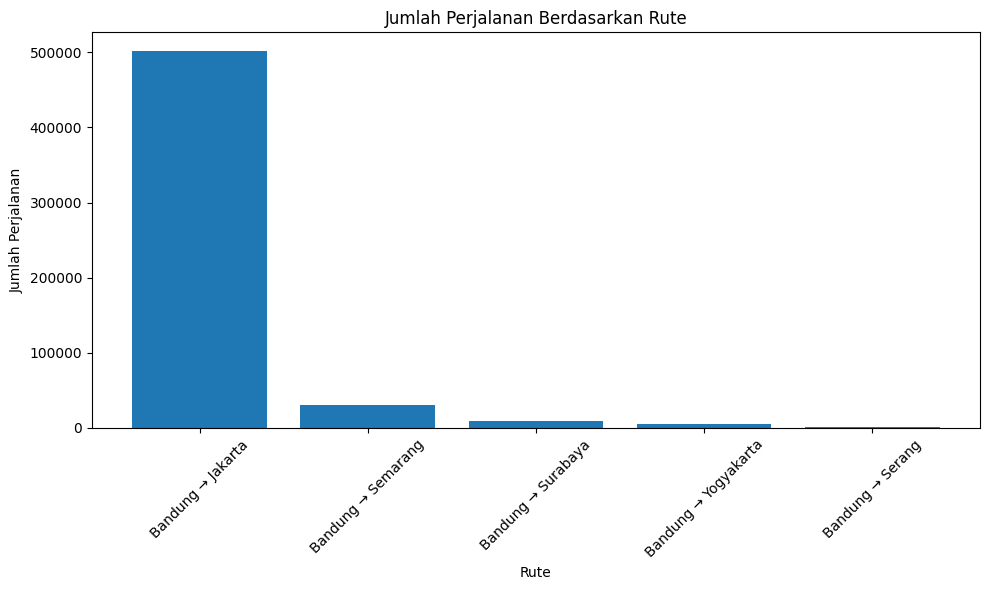

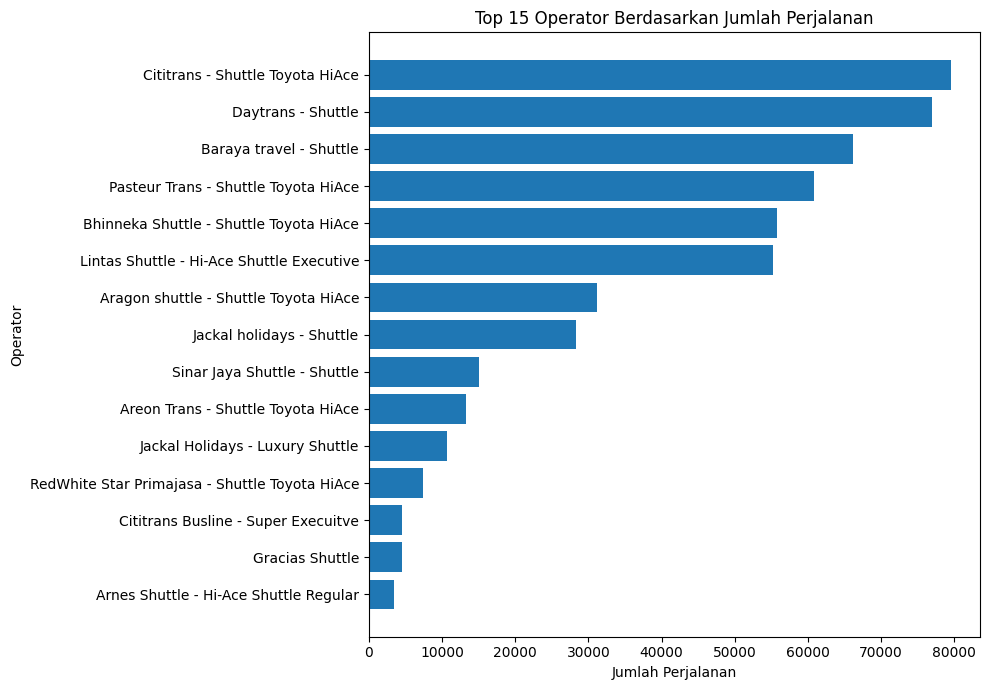

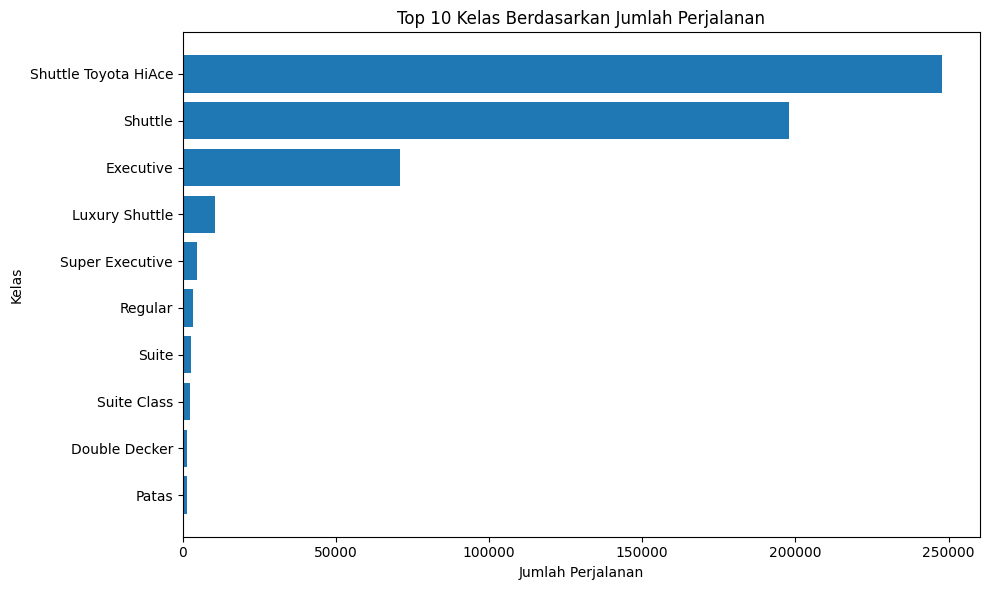

In [ ]:
# ============================================================
# EDA 1 — ANALISIS DEMAND
# TRAVEL DEMAND, PRICING & OCCUPANCY ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA
# ============================================================

file_path = "travel_data_feature_engineered.xlsx"
df_clean = pd.read_excel(file_path)

print("Data berhasil dimuat dari travel_data_feature_engineered.xlsx")
print(f"Jumlah baris: {len(df_clean)}")
print(f"Jumlah kolom: {len(df_clean.columns)}")
print()

# ============================================================
# 1. JUMLAH PERJALANAN BERDASARKAN RUTE
# ============================================================

demand_rute = (
    df_clean["rute"]
    .value_counts()
    .reset_index()
)

demand_rute.columns = [
    "rute",
    "jumlah_perjalanan"
]

print("=" * 60)
print("DEMAND BERDASARKAN RUTE")
print("=" * 60)

print(demand_rute)


# ============================================================
# VISUALISASI RUTE
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    demand_rute["rute"],
    demand_rute["jumlah_perjalanan"]
)

plt.title("Jumlah Perjalanan Berdasarkan Rute")
plt.xlabel("Rute")
plt.ylabel("Jumlah Perjalanan")

plt.xticks(rotation=45)

plt.tight_layout()


# ============================================================
# 2. JUMLAH PERJALANAN BERDASARKAN OPERATOR
# ============================================================

demand_operator = (
    df_clean["nama"]
    .value_counts()
    .reset_index()
)

demand_operator.columns = [
    "operator",
    "jumlah_perjalanan"
]

print("\n" + "=" * 60)
print("TOP 15 OPERATOR BERDASARKAN JUMLAH PERJALANAN")
print("=" * 60)

print(
    demand_operator.head(15)
)


# ============================================================
# VISUALISASI TOP 15 OPERATOR
# ============================================================

top_operator = demand_operator.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_operator["operator"][::-1],
    top_operator["jumlah_perjalanan"][::-1]
)

plt.title("Top 15 Operator Berdasarkan Jumlah Perjalanan")
plt.xlabel("Jumlah Perjalanan")
plt.ylabel("Operator")

plt.tight_layout()


# ============================================================
# 3. JUMLAH PERJALANAN BERDASARKAN KELAS
# ============================================================

demand_kelas = (
    df_clean["kelas"]
    .value_counts()
    .reset_index()
)

demand_kelas.columns = [
    "kelas",
    "jumlah_perjalanan"
]

print("\n" + "=" * 60)
print("DEMAND BERDASARKAN KELAS")
print("=" * 60)

print(demand_kelas)


# ============================================================
# TOP 10 KELAS
# ============================================================

top_kelas = demand_kelas.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_kelas["kelas"][::-1],
    top_kelas["jumlah_perjalanan"][::-1]
)

plt.title("Top 10 Kelas Berdasarkan Jumlah Perjalanan")
plt.xlabel("Jumlah Perjalanan")
plt.ylabel("Kelas")

plt.tight_layout()


# ============================================================
# 4. DEMAND BERDASARKAN JENIS HARI
# ============================================================

demand_jenis_hari = (
    df_clean["jenis_hari"]
    .value_counts()
    .reset_index()
)

demand_jenis_hari.columns = [
    "jenis_hari",
    "jumlah_perjalanan"
]

print("\n" + "=" * 60)
print("DEMAND WEEKDAY VS WEEKEND")
print("=" * 60)

print(demand_jenis_hari)


# ============================================================
# 5. PERSENTASE WEEKDAY VS WEEKEND
# ============================================================

demand_jenis_hari["persentase"] = (
    demand_jenis_hari["jumlah_perjalanan"]
    / demand_jenis_hari["jumlah_perjalanan"].sum()
    * 100
)

print("\nPersentase:")
print(demand_jenis_hari)


# ============================================================
# 6. DEMAND BERDASARKAN WAKTU KEBERANGKATAN
# ============================================================

urutan_waktu = [
    "Pagi",
    "Siang",
    "Sore",
    "Malam"
]

demand_waktu = (
    df_clean["waktu_keberangkatan"]
    .value_counts()
    .reindex(urutan_waktu)
    .reset_index()
)

demand_waktu.columns = [
    "waktu_keberangkatan",
    "jumlah_perjalanan"
]

print("\n" + "=" * 60)
print("DEMAND BERDASARKAN WAKTU KEBERANGKATAN")
print("=" * 60)

print(demand_waktu)


# ============================================================
# 7. DEMAND BERDASARKAN HARI
# ============================================================

urutan_hari = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

demand_hari = (
    df_clean["hari"]
    .value_counts()
    .reindex(urutan_hari)
    .reset_index()
)

demand_hari.columns = [
    "hari",
    "jumlah_perjalanan"
]

print("\n" + "=" * 60)
print("DEMAND BERDASARKAN HARI")
print("=" * 60)

print(demand_hari)


# ============================================================
# 8. DEMAND BERDASARKAN BULAN
# ============================================================

demand_bulan = (
    df_clean
    .groupby(["tahun", "bulan", "nama_bulan"])
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values(["tahun", "bulan"])
)

print("\n" + "=" * 60)
print("DEMAND BERDASARKAN BULAN")
print("=" * 60)

print(demand_bulan)


# ============================================================
# 9. DEMAND PER TANGGAL
# ============================================================

demand_tanggal = (
    df_clean
    .groupby("tanggal")
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("tanggal")
)

print("\n" + "=" * 60)
print("DEMAND PER TANGGAL")
print("=" * 60)

print(demand_tanggal.head(10))


# ============================================================
# 10. TANGGAL DENGAN JUMLAH PERJALANAN TERBANYAK
# ============================================================

top_tanggal = (
    demand_tanggal
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(10)
)

print("\n" + "=" * 60)
print("TOP 10 TANGGAL DENGAN PERJALANAN TERBANYAK")
print("=" * 60)

print(top_tanggal)


# ============================================================
# 11. RINGKASAN EDA DEMAND
# ============================================================

print("\n" + "=" * 60)
print("RINGKASAN EDA DEMAND")
print("=" * 60)

print(
    "Rute dengan perjalanan terbanyak:"
)

print(
    demand_rute.iloc[0]["rute"],
    "-",
    f"{demand_rute.iloc[0]['jumlah_perjalanan']:,}",
    "perjalanan"
)

print(
    "\nOperator dengan perjalanan terbanyak:"
)

print(
    demand_operator.iloc[0]["operator"],
    "-",
    f"{demand_operator.iloc[0]['jumlah_perjalanan']:,}",
    "perjalanan"
)

print(
    "\nKelas dengan perjalanan terbanyak:"
)

print(
    demand_kelas.iloc[0]["kelas"],
    "-",
    f"{demand_kelas.iloc[0]['jumlah_perjalanan']:,}",
    "perjalanan"
)

print(
    "\nWaktu keberangkatan dengan perjalanan terbanyak:"
)

waktu_terbanyak = demand_waktu.loc[
    demand_waktu["jumlah_perjalanan"].idxmax()
]

print(
    waktu_terbanyak["waktu_keberangkatan"],
    "-",
    f"{waktu_terbanyak['jumlah_perjalanan']:,}",
    "perjalanan"
)

print(
    "\nJenis hari dengan perjalanan terbanyak:"
)

hari_terbanyak = demand_jenis_hari.loc[
    demand_jenis_hari["jumlah_perjalanan"].idxmax()
]

print(
    hari_terbanyak["jenis_hari"],
    "-",
    f"{hari_terbanyak['jumlah_perjalanan']:,}",
    "perjalanan"
)

plt.show()


STATISTIK OCCUPANCY KESELURUHAN
count   548,082.00
mean          0.41
std           0.25
min           0.00
25%           0.22
50%           0.43
75%           0.56
max           0.98
Name: occupancy_rate, dtype: float64

Rata-rata occupancy: 41.47%
Median occupancy: 42.86%

DISTRIBUSI KATEGORI OCCUPANCY
  kategori_occupancy  jumlah_perjalanan
0             Rendah             152477
1             Sedang             194526
2             Tinggi             124090
3      Sangat Tinggi              76989


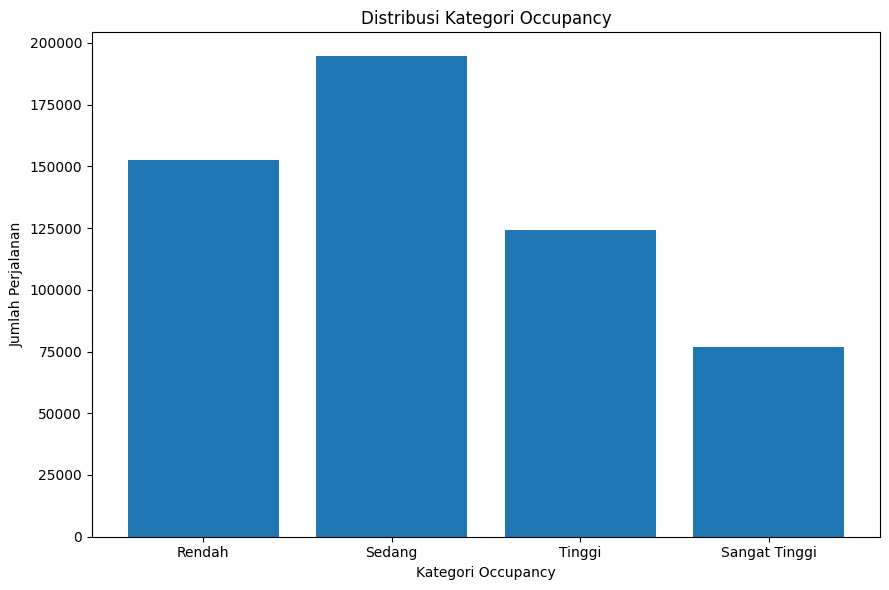


OCCUPANCY BERDASARKAN RUTE
                   rute  jumlah_perjalanan  rata_rata_occupancy  median_occupancy
4  Bandung → Yogyakarta               5173                 0.69              0.78
1    Bandung → Semarang              30420                 0.61              0.60
3    Bandung → Surabaya               9709                 0.43              0.40
0     Bandung → Jakarta             501574                 0.40              0.43
2      Bandung → Serang               1206                 0.36              0.44


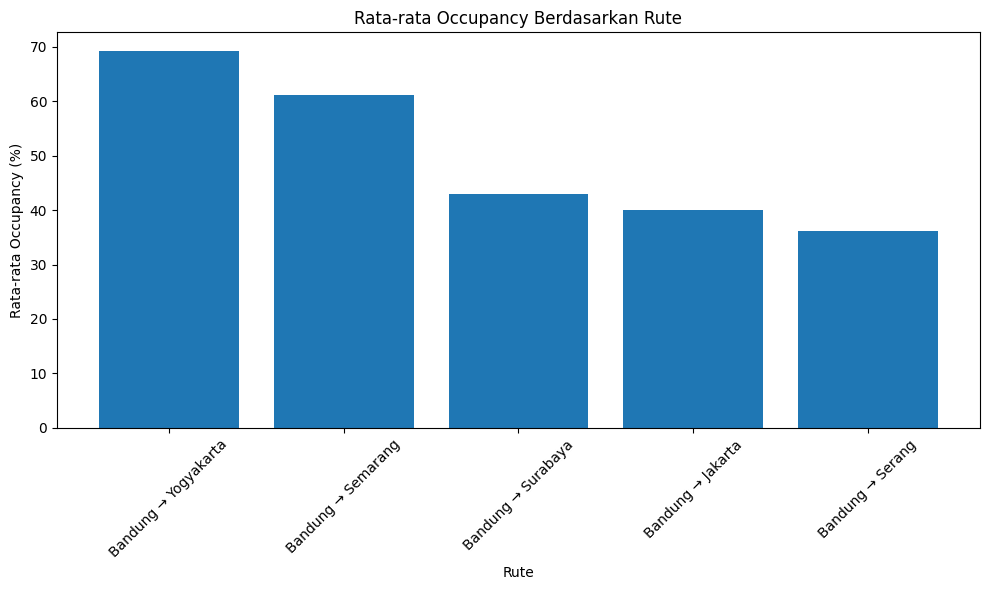


OCCUPANCY WEEKDAY VS WEEKEND
  jenis_hari  jumlah_perjalanan  rata_rata_occupancy  median_occupancy
0    Weekday             395468                 0.41              0.43
1    Weekend             152614                 0.42              0.43

OCCUPANCY BERDASARKAN WAKTU
  waktu_keberangkatan  jumlah_perjalanan  rata_rata_occupancy  median_occupancy
0                Pagi             188914                 0.41              0.43
1               Siang             119480                 0.40              0.43
2                Sore              98832                 0.41              0.43
3               Malam             140856                 0.43              0.43


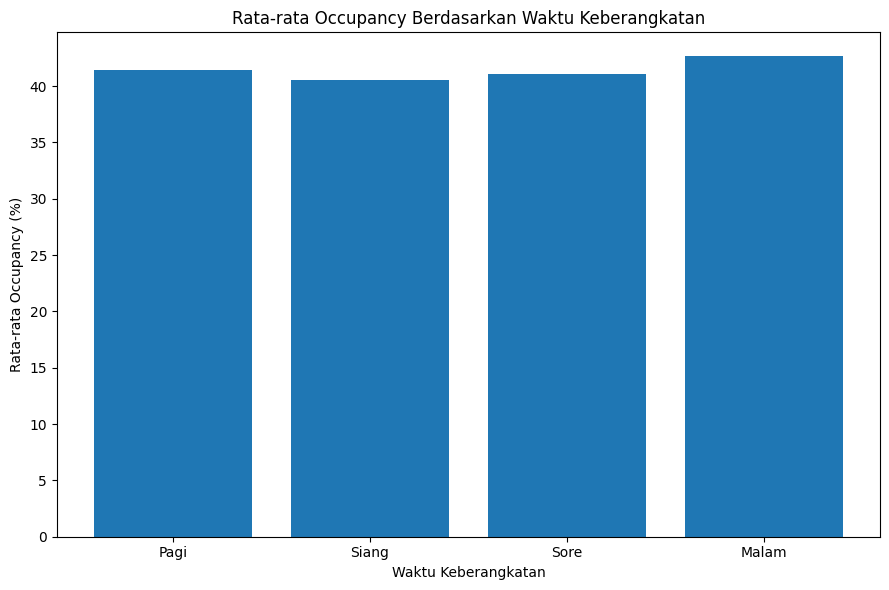


OCCUPANCY BERDASARKAN HARI
        hari  jumlah_perjalanan  rata_rata_occupancy  median_occupancy
0     Monday              77934                 0.43              0.43
1    Tuesday              71254                 0.41              0.43
2  Wednesday              84757                 0.41              0.43
3   Thursday              78698                 0.41              0.43
4     Friday              82825                 0.41              0.43
5   Saturday              76982                 0.42              0.43
6     Sunday              75632                 0.43              0.43

OCCUPANCY BERDASARKAN KELAS
                   kelas  jumlah_perjalanan  rata_rata_occupancy  median_occupancy
18           Suite Class               2384                 0.89              0.88
20       Super Executive               4516                 0.78              0.76
19       Super Execuitve                 52                 0.77              0.76
10              Mini Bus                358

In [ ]:
# ============================================================
# EDA 2 — OCCUPANCY ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. STATISTIK OCCUPANCY KESELURUHAN
# ============================================================

print("=" * 60)
print("STATISTIK OCCUPANCY KESELURUHAN")
print("=" * 60)

print(
    df_clean["occupancy_rate"].describe()
)

print(
    "\nRata-rata occupancy:",
    f"{df_clean['occupancy_rate'].mean():.2%}"
)

print(
    "Median occupancy:",
    f"{df_clean['occupancy_rate'].median():.2%}"
)


# ============================================================
# 2. DISTRIBUSI KATEGORI OCCUPANCY
# ============================================================

occupancy_category = (
    df_clean["kategori_occupancy"]
    .value_counts()
    .reindex(
        [
            "Rendah",
            "Sedang",
            "Tinggi",
            "Sangat Tinggi"
        ]
    )
    .reset_index()
)

occupancy_category.columns = [
    "kategori_occupancy",
    "jumlah_perjalanan"
]

print("\n" + "=" * 60)
print("DISTRIBUSI KATEGORI OCCUPANCY")
print("=" * 60)

print(occupancy_category)


# ============================================================
# 3. VISUALISASI DISTRIBUSI OCCUPANCY
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    occupancy_category["kategori_occupancy"],
    occupancy_category["jumlah_perjalanan"]
)

plt.title("Distribusi Kategori Occupancy")
plt.xlabel("Kategori Occupancy")
plt.ylabel("Jumlah Perjalanan")

plt.tight_layout()
plt.show()


# ============================================================
# 4. RATA-RATA OCCUPANCY BERDASARKAN RUTE
# ============================================================

occupancy_rute = (
    df_clean
    .groupby("rute")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_occupancy=("occupancy_rate", "mean"),
        median_occupancy=("occupancy_rate", "median")
    )
    .reset_index()
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
)

print("\n" + "=" * 60)
print("OCCUPANCY BERDASARKAN RUTE")
print("=" * 60)

print(occupancy_rute)


# ============================================================
# 5. VISUALISASI OCCUPANCY RUTE
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    occupancy_rute["rute"],
    occupancy_rute["rata_rata_occupancy"] * 100
)

plt.title("Rata-rata Occupancy Berdasarkan Rute")
plt.xlabel("Rute")
plt.ylabel("Rata-rata Occupancy (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 6. OCCUPANCY BERDASARKAN JENIS HARI
# ============================================================

occupancy_jenis_hari = (
    df_clean
    .groupby("jenis_hari")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_occupancy=("occupancy_rate", "mean"),
        median_occupancy=("occupancy_rate", "median")
    )
    .reset_index()
)

print("\n" + "=" * 60)
print("OCCUPANCY WEEKDAY VS WEEKEND")
print("=" * 60)

print(occupancy_jenis_hari)


# ============================================================
# 7. OCCUPANCY BERDASARKAN WAKTU KEBERANGKATAN
# ============================================================

urutan_waktu = [
    "Pagi",
    "Siang",
    "Sore",
    "Malam"
]

occupancy_waktu = (
    df_clean
    .groupby("waktu_keberangkatan")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_occupancy=("occupancy_rate", "mean"),
        median_occupancy=("occupancy_rate", "median")
    )
    .reindex(urutan_waktu)
    .reset_index()
)

print("\n" + "=" * 60)
print("OCCUPANCY BERDASARKAN WAKTU")
print("=" * 60)

print(occupancy_waktu)


# ============================================================
# 8. VISUALISASI OCCUPANCY WAKTU
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    occupancy_waktu["waktu_keberangkatan"],
    occupancy_waktu["rata_rata_occupancy"] * 100
)

plt.title("Rata-rata Occupancy Berdasarkan Waktu Keberangkatan")
plt.xlabel("Waktu Keberangkatan")
plt.ylabel("Rata-rata Occupancy (%)")

plt.tight_layout()
plt.show()


# ============================================================
# 9. OCCUPANCY BERDASARKAN HARI
# ============================================================

urutan_hari = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

occupancy_hari = (
    df_clean
    .groupby("hari")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_occupancy=("occupancy_rate", "mean"),
        median_occupancy=("occupancy_rate", "median")
    )
    .reindex(urutan_hari)
    .reset_index()
)

print("\n" + "=" * 60)
print("OCCUPANCY BERDASARKAN HARI")
print("=" * 60)

print(occupancy_hari)


# ============================================================
# 10. OCCUPANCY BERDASARKAN KELAS
# ============================================================

occupancy_kelas = (
    df_clean
    .groupby("kelas")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_occupancy=("occupancy_rate", "mean"),
        median_occupancy=("occupancy_rate", "median")
    )
    .reset_index()
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
)

print("\n" + "=" * 60)
print("OCCUPANCY BERDASARKAN KELAS")
print("=" * 60)

print(occupancy_kelas)


# ============================================================
# 11. TOP KELAS BERDASARKAN OCCUPANCY
# ============================================================

top_kelas_occupancy = (
    occupancy_kelas
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(10)
)

print("\n" + "=" * 60)
print("TOP 10 KELAS BERDASARKAN JUMLAH PERJALANAN")
print("DENGAN INFORMASI OCCUPANCY")
print("=" * 60)

print(top_kelas_occupancy)


# ============================================================
# 12. OCCUPANCY BERDASARKAN OPERATOR
# ============================================================

occupancy_operator = (
    df_clean
    .groupby("nama")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_occupancy=("occupancy_rate", "mean"),
        median_occupancy=("occupancy_rate", "median")
    )
    .reset_index()
)


# ============================================================
# 13. OPERATOR DENGAN VOLUME TERBESAR
# ============================================================

top_operator_volume = (
    occupancy_operator
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(15)
)

print("\n" + "=" * 60)
print("TOP 15 OPERATOR BERDASARKAN VOLUME")
print("=" * 60)

print(top_operator_volume)


# ============================================================
# 14. OPERATOR DENGAN OCCUPANCY TERTINGGI
# ============================================================

# Agar tidak bias oleh operator dengan data sangat sedikit,
# kita gunakan minimal 500 perjalanan.

operator_valid = occupancy_operator[
    occupancy_operator["jumlah_perjalanan"] >= 500
].copy()

top_operator_occupancy = (
    operator_valid
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
    .head(15)
)

print("\n" + "=" * 60)
print("TOP 15 OPERATOR BERDASARKAN RATA-RATA OCCUPANCY")
print("(MINIMAL 500 PERJALANAN)")
print("=" * 60)

print(top_operator_occupancy)


# ============================================================
# 15. RINGKASAN OCCUPANCY
# ============================================================

print("\n" + "=" * 60)
print("RINGKASAN EDA OCCUPANCY")
print("=" * 60)


rute_tertinggi = occupancy_rute.iloc[0]

print(
    "\nRute dengan rata-rata occupancy tertinggi:"
)

print(
    rute_tertinggi["rute"],
    "-",
    f"{rute_tertinggi['rata_rata_occupancy']:.2%}"
)


waktu_tertinggi = (
    occupancy_waktu
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
    .iloc[0]
)

print(
    "\nWaktu dengan rata-rata occupancy tertinggi:"
)

print(
    waktu_tertinggi["waktu_keberangkatan"],
    "-",
    f"{waktu_tertinggi['rata_rata_occupancy']:.2%}"
)


hari_occupancy_tertinggi = (
    occupancy_jenis_hari
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
    .iloc[0]
)

print(
    "\nJenis hari dengan rata-rata occupancy tertinggi:"
)

print(
    hari_occupancy_tertinggi["jenis_hari"],
    "-",
    f"{hari_occupancy_tertinggi['rata_rata_occupancy']:.2%}"
)


kelas_tertinggi = (
    occupancy_kelas
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
    .iloc[0]
)

print(
    "\nKelas dengan rata-rata occupancy tertinggi:"
)

print(
    kelas_tertinggi["kelas"],
    "-",
    f"{kelas_tertinggi['rata_rata_occupancy']:.2%}"
)


print(
    "\nRata-rata occupancy seluruh perjalanan:"
)

print(
    f"{df_clean['occupancy_rate'].mean():.2%}"
)

STATISTIK HARGA
count   548,082.00
mean    131,583.07
std      64,414.93
min      15,000.00
25%     101,000.00
50%     115,051.00
75%     129,870.00
max     630,369.00
Name: harga, dtype: float64

Harga rata-rata: Rp131,583
Harga median: Rp115,051

HARGA BERDASARKAN RUTE
                   rute  jumlah_perjalanan  rata_rata_harga  median_harga  rata_rata_occupancy
3    Bandung → Surabaya               9709       410,462.69    409,001.00                 0.43
4  Bandung → Yogyakarta               5173       344,928.00    374,625.00                 0.69
1    Bandung → Semarang              30420       282,046.67    290,001.00                 0.61
2      Bandung → Serang               1206       144,430.19    161,838.00                 0.36
0     Bandung → Jakarta             501574       114,828.07    113,864.00                 0.40


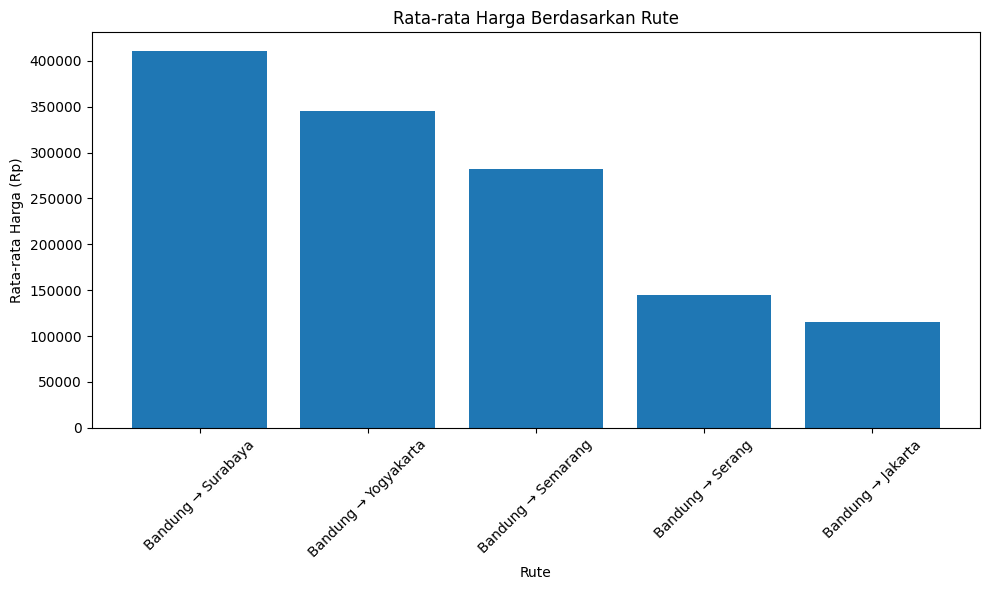


HARGA BERDASARKAN KELAS
                   kelas  jumlah_perjalanan  rata_rata_harga  median_harga  rata_rata_occupancy
12             President                700       501,412.43    499,001.00                 0.54
18           Suite Class               2384       473,368.05    499,500.00                 0.89
17                 Suite               2628       473,173.30    473,001.00                 0.29
2          Double Decker               1449       423,307.96    429,001.00                 0.30
20       Super Executive               4516       346,770.68    349,650.00                 0.78
3             ELF Luxury                315       331,689.08    331,668.00                 0.64
19       Super Execuitve                 52       313,341.35    299,700.00                 0.77
21                   VIP                879       288,973.55    349,001.00                 0.37
14                 Royal                171       282,493.01    284,010.00                 0.34
11             

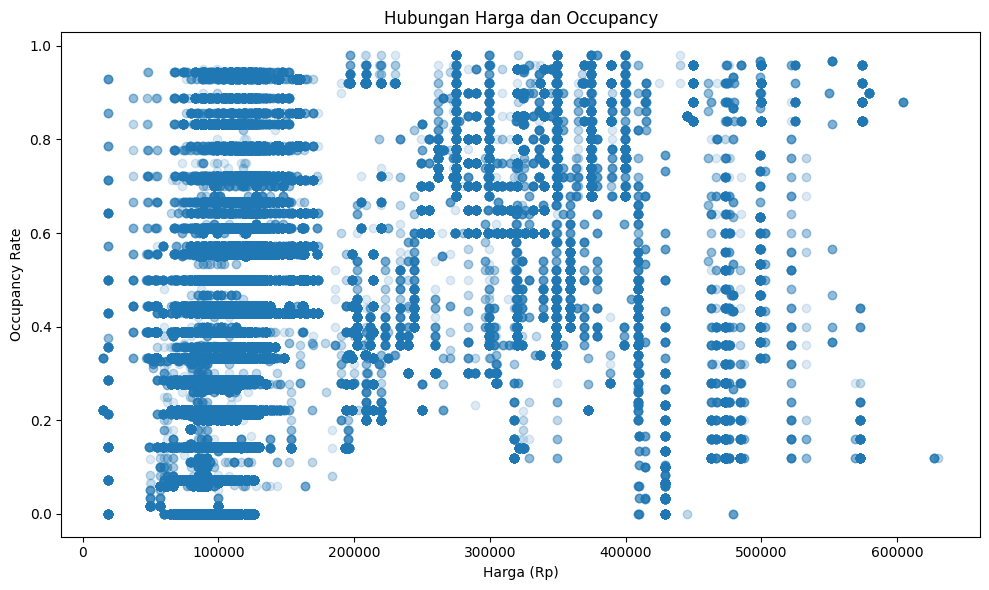


HARGA VS OCCUPANCY PER KELAS
                   kelas  jumlah_perjalanan  rata_rata_harga  rata_rata_occupancy
18           Suite Class               2384       473,368.05                 0.89
20       Super Executive               4516       346,770.68                 0.78
19       Super Execuitve                 52       313,341.35                 0.77
10              Mini Bus                358       122,793.14                 0.69
3             ELF Luxury                315       331,689.08                 0.64
12             President                700       501,412.43                 0.54
16  Shuttle Toyota HiAce             247885       135,770.73                 0.49
6              Executive              70911       134,243.82                 0.49
8         Luxury Shuttle              10649       131,016.53                 0.46
13               Regular               3412        73,453.27                 0.41
21                   VIP                879       288,973.55        

In [ ]:
# ============================================================
# EDA 3 — PRICING ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. STATISTIK HARGA
# ============================================================

print("=" * 60)
print("STATISTIK HARGA")
print("=" * 60)

print(df_clean["harga"].describe())

print(
    "\nHarga rata-rata:",
    f"Rp{df_clean['harga'].mean():,.0f}"
)

print(
    "Harga median:",
    f"Rp{df_clean['harga'].median():,.0f}"
)


# ============================================================
# 2. HARGA BERDASARKAN RUTE
# ============================================================

harga_rute = (
    df_clean
    .groupby("rute")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_harga=("harga", "mean"),
        median_harga=("harga", "median"),
        rata_rata_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
    .sort_values(
        "rata_rata_harga",
        ascending=False
    )
)

print("\n" + "=" * 60)
print("HARGA BERDASARKAN RUTE")
print("=" * 60)

print(harga_rute)


# ============================================================
# 3. VISUALISASI HARGA RUTE
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    harga_rute["rute"],
    harga_rute["rata_rata_harga"]
)

plt.title("Rata-rata Harga Berdasarkan Rute")
plt.xlabel("Rute")
plt.ylabel("Rata-rata Harga (Rp)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 4. HARGA BERDASARKAN KELAS
# ============================================================

harga_kelas = (
    df_clean
    .groupby("kelas")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_harga=("harga", "mean"),
        median_harga=("harga", "median"),
        rata_rata_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
    .sort_values(
        "rata_rata_harga",
        ascending=False
    )
)

print("\n" + "=" * 60)
print("HARGA BERDASARKAN KELAS")
print("=" * 60)

print(harga_kelas)


# ============================================================
# 5. TOP 10 KELAS BERDASARKAN HARGA
# ============================================================

print("\n" + "=" * 60)
print("TOP 10 KELAS DENGAN HARGA TERTINGGI")
print("=" * 60)

print(
    harga_kelas.head(10)
)


# ============================================================
# 6. HARGA BERDASARKAN OPERATOR
# ============================================================

harga_operator = (
    df_clean
    .groupby("nama")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_harga=("harga", "mean"),
        median_harga=("harga", "median"),
        rata_rata_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
)


# ============================================================
# 7. OPERATOR DENGAN VOLUME MINIMAL 500
# ============================================================

harga_operator_valid = harga_operator[
    harga_operator["jumlah_perjalanan"] >= 500
].copy()

harga_operator_valid = (
    harga_operator_valid
    .sort_values(
        "rata_rata_harga",
        ascending=False
    )
)

print("\n" + "=" * 60)
print("OPERATOR DENGAN HARGA RATA-RATA TERTINGGI")
print("(MINIMAL 500 PERJALANAN)")
print("=" * 60)

print(
    harga_operator_valid.head(15)
)


# ============================================================
# 8. HUBUNGAN HARGA DAN OCCUPANCY
# ============================================================

korelasi = df_clean[
    ["harga", "occupancy_rate"]
].corr()

print("\n" + "=" * 60)
print("KORELASI HARGA VS OCCUPANCY")
print("=" * 60)

print(korelasi)


# ============================================================
# 9. SCATTER PLOT HARGA VS OCCUPANCY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["harga"],
    df_clean["occupancy_rate"],
    alpha=0.15
)

plt.title("Hubungan Harga dan Occupancy")
plt.xlabel("Harga (Rp)")
plt.ylabel("Occupancy Rate")

plt.tight_layout()
plt.show()


# ============================================================
# 10. HARGA VS OCCUPANCY BERDASARKAN KELAS
# ============================================================

harga_occupancy_kelas = (
    df_clean
    .groupby("kelas")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_harga=("harga", "mean"),
        rata_rata_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 60)
print("HARGA VS OCCUPANCY PER KELAS")
print("=" * 60)

print(
    harga_occupancy_kelas
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
)


# ============================================================
# 11. RUTE × KELAS
# ============================================================

rute_kelas = (
    df_clean
    .groupby(["rute", "kelas"])
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_harga=("harga", "mean"),
        rata_rata_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
)


# ============================================================
# 12. KOMBINASI RUTE × KELAS DENGAN OCCUPANCY TERTINGGI
# ============================================================

rute_kelas_valid = rute_kelas[
    rute_kelas["jumlah_perjalanan"] >= 100
].copy()

top_rute_kelas = (
    rute_kelas_valid
    .sort_values(
        "rata_rata_occupancy",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 60)
print("TOP 20 RUTE × KELAS BERDASARKAN OCCUPANCY")
print("(MINIMAL 100 PERJALANAN)")
print("=" * 60)

print(top_rute_kelas)


# ============================================================
# 13. RINGKASAN PRICING
# ============================================================

print("\n" + "=" * 60)
print("RINGKASAN EDA PRICING")
print("=" * 60)

rute_harga_tertinggi = harga_rute.iloc[0]

print(
    "\nRute dengan harga rata-rata tertinggi:"
)

print(
    rute_harga_tertinggi["rute"],
    "-",
    f"Rp{rute_harga_tertinggi['rata_rata_harga']:,.0f}"
)

kelas_harga_tertinggi = harga_kelas.iloc[0]

print(
    "\nKelas dengan harga rata-rata tertinggi:"
)

print(
    kelas_harga_tertinggi["kelas"],
    "-",
    f"Rp{kelas_harga_tertinggi['rata_rata_harga']:,.0f}"
)

print(
    "\nKorelasi harga vs occupancy:"
)

print(
    korelasi.loc[
        "harga",
        "occupancy_rate"
    ]
)

In [ ]:
df_clean[["harga", "occupancy_rate"]].corr()

,harga,occupancy_rate
harga,1.00,0.32
occupancy_rate,0.32,1.00


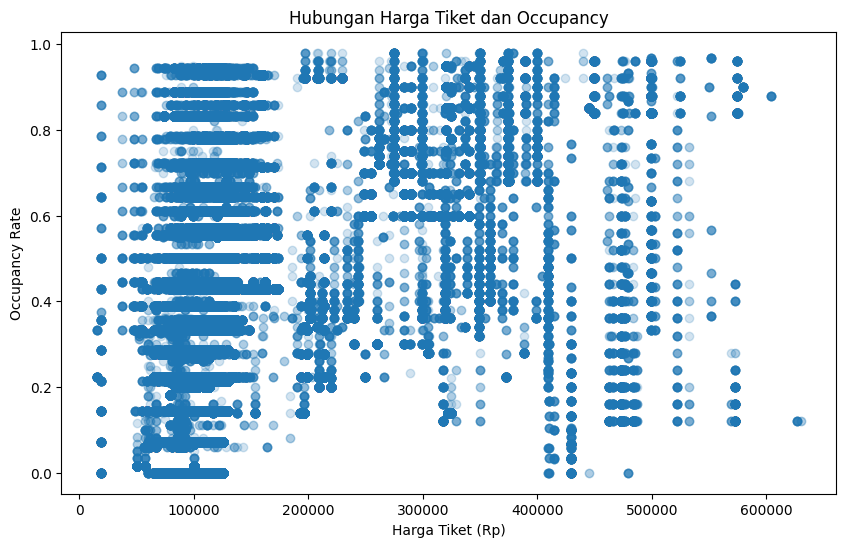

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["harga"],
    df_clean["occupancy_rate"],
    alpha=0.2
)

plt.title("Hubungan Harga Tiket dan Occupancy")
plt.xlabel("Harga Tiket (Rp)")
plt.ylabel("Occupancy Rate")

plt.show()

In [ ]:
harga_occupancy_kelas = (
    df_clean
    .groupby("kelas")
    .agg(
        jumlah_perjalanan=("id_travel", "count"),
        rata_rata_harga=("harga", "mean"),
        rata_rata_occupancy=("occupancy_rate", "mean")
    )
)

harga_occupancy_kelas = (
    harga_occupancy_kelas[
        harga_occupancy_kelas["jumlah_perjalanan"] >= 100
    ]
    .sort_values("rata_rata_occupancy", ascending=False)
)

harga_occupancy_kelas["rata_rata_harga"] = (
    harga_occupancy_kelas["rata_rata_harga"].round(0)
)

harga_occupancy_kelas["rata_rata_occupancy"] = (
    harga_occupancy_kelas["rata_rata_occupancy"] * 100
).round(1)

harga_occupancy_kelas

,jumlah_perjalanan,rata_rata_harga,rata_rata_occupancy
kelas,,,
Suite Class,2384,"473,368.00",88.90
Super Executive,4516,"346,771.00",77.90
Mini Bus,358,"122,793.00",68.50
ELF Luxury,315,"331,689.00",64.10
President,700,"501,412.00",54.10
Shuttle Toyota HiAce,247885,"135,771.00",49.50
Executive,70911,"134,244.00",49.20
Luxury Shuttle,10649,"131,017.00",46.50
Regular,3412,"73,453.00",40.90
